# Gravitational Sonar v64 — five independent experiments

**Run all in a GPU runtime.** The first cell mounts Google Drive in Colab; finish that authorization before leaving. Everything needed is embedded here. Each experiment runs in its own Python process, starts from its own seed, constructs its own target, and writes its own checkpoints and diagnostics. No fit initializes another experiment.

The default `overnight` profile gives each main fit **45 minutes of training plus 8 minutes for diagnostics**, then continues. Ringdown has a 10-minute cap. Extra JP-prior and ten-seed floor runs follow the five main branches. An eight-hour limit stops *starting extras*; an already-running attempt can finish its budget. These limits provide coverage, **not a guarantee of convergence or completion before a Colab session disconnects**. `full` removes wall-clock limits and uses all v23 evaluation caps. `smoke` exercises all five with tiny budgets.

| Branch | Target and change | What its result means |
|---|---|---|
| Dissipation | Kerr + balanced coordinate-time torque $dp_\phi/dt=-A_0r^{-7/2}$ | Jointly fit metric, ICs, pivot torque amplitude and radial exponent. Baseline orbit is eccentric/inclined; the $\dot r\sim-r^{-3}$ interpretation is the weak-field circular limit. |
| Gabor | v23 target; FFT magnitude loss becomes overlapping Hann STFT magnitudes | Joint waveform + time-frequency fitting. Select `gaussian` for a Gaussian-window Gabor transform. |
| Beyond Kerr | JP injection, $\epsilon_3=2$ by default; Ricci/boundary off | Reconstruct metric, then rank a fixed-chart Kerr/JP/EOB toy library. Optional second run restores priors. |
| EOB | Proposed $A(r)=1-2/r+2\nu/r^3$ metric, $\nu=0.089$ | **Synthetic EOB-inspired metric reconstruction, not GW190814 data and not SEOBNR.** |
| Ringdown | Independent noisy Kerr QNM injections | Recover final mass/spin; compare one/two modes and start-time sensitivity. No merger or generic-metric perturbation solver. |

The ten floor runs measure optimizer repeatability, **not a calibrated detection threshold**. The ringdown experiment does not depend on an inspiral fit.

Baseline: attached `Sonar_v23_Learn_Dissipation_Constant (4)(1).ipynb`. Network architecture, quadrupole prescription, coordinate-time RK4, 74-parameter layout in the control branches (75 in dissipation), Adam update and LM ladder are retained. The unused external BFGS monkey patch is omitted: the baseline ladder uses SciPy least squares with `method="lm"`.


## 1. Settings and destination

Usually change only `RUN_TAG`, `PROFILE`, `EPS3`, and the budgets. Keep a tag to resume unchanged settings; use a new tag when changing physics or worker code. All five main experiments are enabled. The floor runs and paired JP run are additional rows.

In [1]:
import os, sys, json, time, subprocess, importlib.util, hashlib
from pathlib import Path

# Choose a GPU runtime in Colab before Run all. Existing Colab JAX is kept.
PROFILE = os.environ.get('SONAR_PROFILE', 'overnight')  # 'overnight', 'full', 'smoke'
RUN_TAG = os.environ.get('SONAR_RUN_TAG', 'v64_amplitude_and_power')
RESUME = True
MOUNT_GOOGLE_DRIVE = True
RUN_FLOOR_SEEDS = PROFILE != 'smoke'
FLOOR_SEEDS = list(range(10))
RUN_JP_PRIOR_COMPARISON = PROFILE != 'smoke'
DISSIPATION_ORBIT = 'baseline'  # 'circular' gives an initially circular equatorial inspiral
EPS3 = 2.0                     # Set 0.3 for the harder original target; included in library.
A0 = (32.0/5.0)*1e-3           # G=c=M=mu_specific=1; weak-field EMRI q=1e-3 normalization.
R_REF = 10.0                   # Fixed pivot radius in M units.
N_TRUE = 3.5                    # Injection ONLY: signed radial power is -N_TRUE.
N_INITIAL = 2.0                 # Independent learner initialization, deliberately not 3.5.
A_REF_TRUE = A0 * R_REF**(-3.5) # Positive torque magnitude at the pivot; independent of N_TRUE.
POWER_PROFILE_POINTS = 21
TORQUE_GRID_POINTS = 9          # Final conditional log-amplitude vs exponent map.
SEED = 0
CORE_TRAIN_MINUTES = 45
FLOOR_TRAIN_MINUTES = 15
DIAGNOSTIC_GRACE_MINUTES = 8    # Worker gets this extra time before hard termination.
TOTAL_WALL_HOURS = 8           # Main five first; optional extra runs use remaining time.
POLL_SECONDS = 5
EXTENDED_DIAGNOSTICS = True
FLUX_PROFILE_POINTS = 41
RUNG_DIAGNOSTIC_SECONDS = 120
FINAL_DIAGNOSTIC_SECONDS = 240
CHIRP_TC = None                 # Only set an independently justified t_c, in M units.

# A persistent destination lets an interrupted run resume its saved parameters.
try:
    from google.colab import drive
    if MOUNT_GOOGLE_DRIVE: drive.mount('/content/drive')
    base = Path('/content/drive/MyDrive') if MOUNT_GOOGLE_DRIVE else Path.cwd()
except ImportError:
    base = Path.cwd()
ROOT = Path(os.environ.get('SONAR_OUTPUT_ROOT', str(base/'Sonar_v64_runs'))) / RUN_TAG
ROOT.mkdir(parents=True, exist_ok=True)
WORK_DIR = ROOT/'code'; WORK_DIR.mkdir(exist_ok=True)
print('Output directory:', ROOT)
print('Profile:', PROFILE, '| Main training budget:', CORE_TRAIN_MINUTES, 'minutes per branch')
print('The time budgets limit attempts, not convergence. Compilation and diagnostics also take time.')

# Install only missing packages. Do not replace a working GPU JAX installation.
requirements = {'numpy':'numpy','scipy':'scipy','matplotlib':'matplotlib','qnm':'qnm==0.4.4'}
missing=[package for module,package in requirements.items() if importlib.util.find_spec(module) is None]
if importlib.util.find_spec('jax') is None: missing.append('jax[cpu]')
if missing:
    subprocess.check_call([sys.executable,'-m','pip','install','--quiet','--disable-pip-version-check',*missing])
# Only workers import JAX; the notebook kernel does not reserve GPU memory.
os.chdir(WORK_DIR)


Mounted at /content/drive
Output directory: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power
Profile: overnight | Main training budget: 45 minutes per branch
The time budgets limit attempts, not convergence. Compilation and diagnostics also take time.


### New: learn the amplitude AND the radial power

The dissipation branch now fits
$$\frac{dp_\phi}{dt}=-A_{\rm ref}\left(\frac{r}{r_{\rm ref}}\right)^{-n},\qquad A_{\rm ref}=A_{\rm ref}^{(0)}e^\alpha,\quad r_{\rm ref}=10M.$$
Here `A_REF_TRUE` supplies a normalization and the injected pivot amplitude; **alpha and n are both trained**, together with the metric and ICs. `n=3.5` is used only to generate the injected radial law; the learner starts at `N_INITIAL=2.0` and half the injected pivot amplitude. `n` is an unconstrained scalar, with no penalty pulling it toward the injected value. Its signed radial power is `-n`.

The fixed pivot makes amplitude mean the torque magnitude at 10 M for every exponent. Defaults reproduce the previous injected torque exactly: `A_REF_TRUE = 0.0064 * 10**(-3.5)`. Changing `N_TRUE` leaves this pivot amplitude fixed; changing `N_INITIAL` changes only the learner. Fitted amplitude/exponent values are saved in checkpoints, logs and the summary table.

D1 includes the exponent among its labeled Jacobian columns. D3 adds exponent slices at each LM rung and a final two-dimensional amplitude–exponent loss map. D5 separately swaps amplitude/exponent while holding the learned metric and fitted ICs, in addition to swapping the full torque law. All learned-metric diagnostics propagate the learned exponent; truth-oracle checks use the injected exponent. The balancing energy term uses exactly the same torque.

This branch has **75 parameters**. Existing 74-parameter dissipation checkpoints are incompatible and are not padded or silently reinterpreted. The new default run tag avoids overwriting earlier runs. A narrow radial range can leave amplitude and exponent strongly correlated; the new diagnostics expose that possibility. The default orbit remains the original eccentric/inclined orbit; choose `DISSIPATION_ORBIT='circular'` if desired.


## 2. Physics worker — written here, run in fresh processes below

The `%%writefile` cells write ordinary Python source. They **do not run training in the notebook kernel**. Edit these functions directly if desired, then run all cells from the top. A worker source hash is saved with each run.

For dissipation, define $T=dp_\phi/dt$. Before dividing the affine-time Hamilton equations by $u^t=\partial H/\partial p_t$, add

$$F_t=-u^\phi T,\qquad F_\phi=u^tT.$$

Then $dH/d\tau=u^tF_t+u^\phi F_\phi=0$ and $dE/dt=\Omega_\phi\,dL_z/dt$, with $E=-p_t$. Both terms use the **same fitted amplitude and exponent**. This preserves the initial mass-shell value analytically; RK4 still has numerical drift, and the initial shell penalty is retained.

With specific $L=\sqrt r$ in Newtonian circular motion, $dL/dt=(2\sqrt r)^{-1}\dot r=-A_0r^{-7/2}$ gives $\dot r=-2A_0r^{-3}$, hence $r^4(t)=r_0^4-8A_0t$. This is an intuition/diagnostic, not the imposed radial equation for generic Kerr motion. Default $A_0=0.0064$ corresponds to leading Newtonian normalization with $q=10^{-3}$ in $G=c=M=1$ units.

Set `DISSIPATION_ORBIT='circular'` for an initially circular equatorial target. The learner fits all 75 parameters; its polar-IC bounds expand to contain the equator. With the default `'baseline'`, the original eccentric/inclined ICs remain. Both $p_{r,0}$ and $p_{\theta,0}$ are fixed at zero as in v23; **this is a restricted turning-point family, not WLOG for generic inspirals**.

The other orbit branches retain v23's legacy constant affine-time torque with $dp_t=0$, so their mass-shell drift is explicitly reported. For JP/EOB, only the proposed Kerr spatial momenta are reused; the truth energy is recomputed from that metric's mass shell.


### Imports and v23 metric network

In [2]:
%%writefile sonar_v64_worker.py
# Sonar v64: fresh process, independent target, parameters, optimizer and outputs.
import os, sys, json, time, math, traceback, hashlib, platform
from pathlib import Path
import numpy as np
import scipy
from scipy import optimize
from scipy.optimize import least_squares
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax, random, tree_util
from jax.flatten_util import ravel_pytree
CONFIG = json.loads(Path(sys.argv[1]).read_text())
OUT = Path(CONFIG["output"]); OUT.mkdir(parents=True, exist_ok=True)
START = time.monotonic()
a_true = float(CONFIG.get("spin", .9))
rp_true, ra_true, theta_min_true = 10., 14., math.pi/4
N_TIME = int(CONFIG.get("n_time", 1000))
T_END = float(CONFIG.get("t_end", 1260.))
t_full = jnp.linspace(0., T_END, N_TIME, dtype=jnp.float32)
theta_observed = jnp.asarray([math.pi/4], dtype=jnp.float32)
SEED = int(CONFIG.get("seed", 0))
def init_network(key, dtype=jnp.float32):
    # Same Linear(2,8) -> SiLU -> Linear(8,5) architecture: 69 scalars.
    k1, k2, k3, k4 = random.split(key, 4)
    l1 = 1.0 / math.sqrt(2.0)
    l2 = 1.0 / math.sqrt(8.0)
    return {
        "w1": random.uniform(k1, (8, 2), dtype, -l1, l1),
        "b1": random.uniform(k2, (8,), dtype, -l1, l1),
        "w2": random.uniform(k3, (5, 8), dtype, -l2, l2),
        "b2": random.uniform(k4, (5,), dtype, -l2, l2),
    }

def network_apply(params, x):
    hidden = jax.nn.silu(params["w1"] @ x + params["b1"])
    return params["w2"] @ hidden + params["b2"]

def nn_input(r, theta):
    return jnp.stack((1.0 / r, jnp.cos(theta) ** 2))

def Kerr(x, a, M=1.0):
    r, theta = x[1], x[2]
    delta = r**2 - 2.0 * M * r + a**2
    sigma = r**2 + a**2 * jnp.cos(theta) ** 2
    A = (r**2 + a**2) ** 2 - delta * a**2 * jnp.sin(theta) ** 2
    g_tt = -(1.0 - 2.0 * M * r / sigma)
    g_rr = sigma / delta
    g_thth = sigma
    g_phph = A / sigma * jnp.sin(theta) ** 2
    g_tph = (-2.0 * M * r / sigma) * a * jnp.sin(theta) ** 2
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))

def g_Kerr(r, theta, M=1.0, a=a_true):
    return Kerr(jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r))), a, M)

def NN_Ansatz(r, theta, fields):
    u = 1.0 / r
    g_tt = -1.0 + u * fields[0]
    g_rr = 1.0 / (1.0 + u * fields[1])
    g_thth = r**2 + fields[2]
    g_phph = jnp.sin(theta) ** 2 * (r**2 + fields[3])
    g_tph = u * jnp.sin(theta) ** 2 * fields[4]
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))

def metric_from_network(params, r, theta):
    return NN_Ansatz(r, theta, network_apply(params, nn_input(r, theta)))


Writing sonar_v64_worker.py


### Injected metrics

In [3]:
%%writefile -a sonar_v64_worker.py
# Johannsen-Psaltis epsilon_3 metric, copied from attached v29.
def JP(x, a, eps3, M=1.):
    r, th = x[1], x[2]
    s2 = jnp.sin(th)**2
    delta = r*r - 2*M*r + a*a
    sigma = r*r + a*a*jnp.cos(th)**2
    h = eps3*M**3*r/sigma**2
    gtt = -(1 - 2*M*r/sigma)*(1+h)
    grr = sigma*(1+h)/(delta+a*a*h*s2)
    gpp = s2*(r*r+a*a+2*a*a*M*r*s2/sigma) + h*a*a*(sigma+2*M*r)*s2*s2/sigma
    gtp = -2*M*r*a*s2*(1+h)/sigma
    z = jnp.zeros_like(r)
    return jnp.array([[gtt,z,z,gtp],[z,grr,z,z],[z,z,sigma,z],[gtp,z,z,gpp]])

def EOB(x, a=0., M=1., nu=.089):
    # Deliberately only the proposed A-potential toy: not a full EOB Hamiltonian.
    r, th = x[1], x[2]
    A = 1 - 2*M/r + 2*nu*(M/r)**3
    return jnp.diag(jnp.array([-A, 1/A, r*r, r*r*jnp.sin(th)**2]))

def metric(x):
    family = CONFIG.get("truth_metric", "kerr")
    if family == "jp": return JP(x, a_true, CONFIG["eps3"])
    if family == "eob": return EOB(x, nu=CONFIG.get("nu", .089))
    return Kerr(x, a_true)

def g_Kerr(r, theta, M=1., a=None):
    # Legacy diagnostics name; now explicitly the injected reference metric.
    return metric(jnp.array([0., r, theta, 0.]))


Appending to sonar_v64_worker.py


### Initial conditions and mass-shell energy

In [4]:
%%writefile -a sonar_v64_worker.py
R_LO, R_HI = 6.2, 20.
TH_LO = .1
# A circular equatorial truth must be inside, not outside, the IC parameter bounds.
TH_HI = math.pi/2 + .1 if CONFIG.get("orbit") == "circular" else math.pi/2 - .1
def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_softplus(x):
    return jnp.log(jnp.expm1(x))

def encode_ic(r, theta, pt, Lz):
    return jnp.asarray([
        logit((r - R_LO) / (R_HI - R_LO)),
        logit((theta - TH_LO) / (TH_HI - TH_LO)),
        inv_softplus(-pt),
        inv_softplus(Lz),
    ], dtype=jnp.float32)

def decode_ic(z):
    r = R_LO + (R_HI - R_LO) * jax.nn.sigmoid(z[0])
    theta = TH_LO + (TH_HI - TH_LO) * jax.nn.sigmoid(z[1])
    pt = -jax.nn.softplus(z[2])
    Lz = jax.nn.softplus(z[3])
    return jnp.asarray([0., r, theta, 0., pt, 0., 0., Lz])
def solve_ELQ(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    delta_p = r_p**2 - 2.0 * M * r_p + a**2
    delta_a = r_a**2 - 2.0 * M * r_a + a**2

    def equations(v):
        E, Lz = v
        Qp = (((r_p**2 + a**2) * E - a * Lz) ** 2
              - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p
        F0 = (((r_a**2 + a**2) * E - a * Lz) ** 2
              - delta_a * ((Lz - a * E) ** 2 + mu**2 * r_a**2 + Qp))
        F1 = Qp - math.cos(theta_min) ** 2 * (
            a**2 * (mu**2 - E**2) + Lz**2 / math.sin(theta_min) ** 2
        )
        return (F0, F1)

    E0 = math.sqrt(1.0 - 2.0 * M / (r_p + r_a))
    L0 = math.sqrt(M * (r_p + r_a) / 2.0)
    E, Lz = optimize.fsolve(equations, (E0, L0))
    Q = ((((r_p**2 + a**2) * E - a * Lz) ** 2
         - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p)
    return E, Lz, Q

def make_u0(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    E, Lz, _ = solve_ELQ(r_p, r_a, theta_min, M, a, mu)
    return np.asarray([0.0, r_p, theta_min, 0.0, -E, 0.0, 0.0, Lz])

def energy_from_mass_shell(g, spatial_p, mu=1.):
    invg = jnp.linalg.inv(g)
    A = invg[0,0]
    B = 2*jnp.dot(invg[0,1:], spatial_p)
    C = spatial_p @ invg[1:,1:] @ spatial_p + mu**2
    disc = B*B - 4*A*C
    # This root has u^t = +sqrt(disc)/2 for an exterior timelike state.
    pt = (-B+jnp.sqrt(disc))/(2*A)
    return -pt

def make_truth_ic():
    if CONFIG.get("orbit") == "circular":
        r, a = rp_true, a_true
        d = r**.75 * np.sqrt(r**1.5 - 3*np.sqrt(r)+2*a)
        E = (r**1.5-2*np.sqrt(r)+a)/d
        L = (r*r-2*a*np.sqrt(r)+a*a)/d
        return jnp.array([0.,r,np.pi/2,0.,-E,0.,0.,L], dtype=jnp.float64)
    u = jnp.asarray(make_u0(rp_true, ra_true, theta_min_true), dtype=jnp.float64)
    # Kerr E,L are only a starting proposal in JP/EOB. Put truth ON its own shell.
    if CONFIG.get("truth_metric") in ("jp", "eob"):
        u = u.at[4].set(-energy_from_mass_shell(metric(u[:4]), u[5:]))
    return u

params = {"metric": init_network(random.PRNGKey(SEED)),
          "ic": encode_ic(9., .90, -.90, 2.30),
          "log_dissipation_scale": jnp.asarray(math.log(.5),dtype=jnp.float32)}
TRUTH_EXPONENT = float(CONFIG.get('truth_exponent',3.5))
R_REF = float(CONFIG.get('r_ref',10.))
A_REF = float(CONFIG.get('a_ref',CONFIG.get('A0',.0064)*R_REF**(-3.5)))
LEARN_EXPONENT = bool(CONFIG.get('learn_exponent',False))
if R_REF<=0 or A_REF<=0: raise ValueError('r_ref and a_ref must be positive')
if LEARN_EXPONENT:
    if CONFIG.get('force')!='radial_balanced':raise ValueError('Trainable exponent requires radial_balanced force')
    params['dissipation_exponent']=jnp.asarray(CONFIG.get('initial_exponent',2.),dtype=jnp.float32)
assert ravel_pytree(params)[0].size == (75 if LEARN_EXPONENT else 74)

def learned_exponent(joint):
    # The radial branch always passes its trainable scalar explicitly.
    return joint['dissipation_exponent'] if LEARN_EXPONENT else jnp.asarray(TRUTH_EXPONENT)

def torque_parameters(joint):
    if CONFIG.get('force')!='radial_balanced':return {}
    alpha=float(joint['log_dissipation_scale']);power=float(learned_exponent(joint))
    return dict(A_ref=float(A_REF*np.exp(alpha)),A_ref_true=A_REF,r_ref=R_REF,
                exponent=power,signed_radial_power=-power,exponent_true=TRUTH_EXPONENT,
                exponent_initial=float(CONFIG.get('initial_exponent',2.)),exponent_error=power-TRUTH_EXPONENT,
                exponent_trainable=LEARN_EXPONENT)
U0 = make_truth_ic()
I4, Z4 = jnp.eye(4), jnp.zeros((4,4))
SYMPLECTIC = jnp.block([[Z4,I4],[-I4,Z4]])


Appending to sonar_v64_worker.py


### Hamilton equations, RK4 and quadrupole waveform

In [5]:
%%writefile -a sonar_v64_worker.py
def dissipation(state, grad_H, exponent=None):
    kind = CONFIG.get("force", "constant_legacy")
    if kind == "none": return jnp.zeros_like(state)
    if kind == "constant_legacy":
        return jnp.zeros_like(state).at[7].set(-1e-3)
    # T = dp_phi/dt. F below is added to the affine-time Hamilton equations.
    n = TRUTH_EXPONENT if exponent is None else exponent
    # A_REF is a fixed normalization; exp(alpha) learns its multiplicative amplitude.
    T = -A_REF * (state[1]/R_REF)**(-n)
    return jnp.zeros_like(state).at[4].set(-grad_H[7]*T).at[7].set(grad_H[4]*T)

# D0: one Hamiltonian implementation for training and metric-swap diagnostics.
def hamiltonian_of(g_fn, state):
    return .5 * state[4:] @ jnp.linalg.inv(g_fn(state[1],state[2])) @ state[4:]

def g_learned(joint):
    return lambda r,th:metric_from_network(joint['metric'],r,th)

def g_truth(r,th):
    return metric(jnp.array([0.,r,th,0.]))

def hamiltonian_network(params, state):
    return hamiltonian_of(lambda r,th:metric_from_network(params,r,th),state)

def hamiltonian_kerr(state):
    return hamiltonian_of(g_truth,state)

def hamiltonian_rhs(H, state, scale=1., exponent=None):
    grad_H = jax.grad(H)(state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + scale*dissipation(state, grad_H, exponent)
    return (du_dtau/grad_H[4]).at[0].set(1.)

def H_function(params, state, log_dissipation_scale, exponent=None):
    return hamiltonian_rhs(lambda u: hamiltonian_network(params,u), state, jnp.exp(log_dissipation_scale), exponent)

def H_Kerr(state):
    return hamiltonian_rhs(hamiltonian_kerr, state)
def rhs_of(g_fn,state,log_scale,exponent=None):
    # Reuses the production force, including the balanced F_t and F_phi terms.
    return hamiltonian_rhs(lambda u:hamiltonian_of(g_fn,u),state,jnp.exp(log_scale),exponent)

def roll(g_fn,u0,t_array,log_scale,exponent=None):
    return integrate(lambda _,u:rhs_of(g_fn,u,log_scale,exponent),u0,t_array)

def wave_of(traj,t_array):
    # Match ALL production observers, not just observer zero.
    return jax.vmap(lambda th:create_gravityWave(t_array,traj,a_true,theta_obs=th))(theta_observed.astype(t_array.dtype))

def rk4_step(rhs, time, state, step):
    k1 = rhs(time, state)
    k2 = rhs(time + step / 2.0, state + step * k1 / 2.0)
    k3 = rhs(time + step / 2.0, state + step * k2 / 2.0)
    k4 = rhs(time + step, state + step * k3)
    return state + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0

def integrate(rhs, y0, t_array):
    step = t_array[1] - t_array[0]

    def scan_step(state, time):
        next_state = rk4_step(rhs, time, state, step)
        return next_state, next_state

    _, tail = lax.scan(scan_step, y0, t_array[:-1])
    return jnp.concatenate((y0[None, :], tail), axis=0)

def integrate_network(params, y0, t_array, log_dissipation_scale, exponent=None):
    return integrate(
        lambda time, state: H_function(params, state, log_dissipation_scale, exponent),
        y0, t_array,
    )

def integrate_kerr(y0, t_array):
    return integrate(lambda time, state: H_Kerr(state), y0, t_array)
def d2_dt2(v, dt):
    first = 2.0 * v[..., 0] - 5.0 * v[..., 1] + 4.0 * v[..., 2] - v[..., 3]
    middle = v[..., :-2] - 2.0 * v[..., 1:-1] + v[..., 2:]
    last = 2.0 * v[..., -1] - 5.0 * v[..., -2] + 4.0 * v[..., -3] - v[..., -4]
    return jnp.concatenate((first[..., None], middle, last[..., None]), axis=-1) / dt**2

def Soln2Orbit(soln, a):
    r, theta, phi = soln[:, 1], soln[:, 2], soln[:, 3]
    return jnp.stack((
        r * jnp.sin(theta) * jnp.cos(phi),
        r * jnp.sin(theta) * jnp.sin(phi),
        r * jnp.cos(theta),
    ))

def Q_ij(orbit, mu=1.0):
    outer = jnp.einsum("in,jn->ijn", orbit, orbit)
    r2 = jnp.sum(orbit**2, axis=0)
    return mu * (outer - jnp.eye(3, dtype=orbit.dtype)[:, :, None] * r2[None, None, :] / 3.0)

def Observer_Basis(theta_obs, phi_obs):
    n = jnp.stack((jnp.sin(theta_obs) * jnp.cos(phi_obs),
                   jnp.sin(theta_obs) * jnp.sin(phi_obs),
                   jnp.cos(theta_obs)))
    p = jnp.stack((jnp.cos(theta_obs) * jnp.cos(phi_obs),
                   jnp.cos(theta_obs) * jnp.sin(phi_obs),
                  -jnp.sin(theta_obs)))
    q = jnp.stack((-jnp.sin(phi_obs), jnp.cos(phi_obs), jnp.zeros_like(phi_obs)))
    return n, p, q

def project_waveform(Qdd, theta_obs=0.0, phi_obs=0.0, D=1.0):
    _, p, q = Observer_Basis(theta_obs, phi_obs)
    e_plus = jnp.einsum("i,j->ij", p, p) - jnp.einsum("i,j->ij", q, q)
    e_cross = jnp.einsum("i,j->ij", p, q) + jnp.einsum("i,j->ij", q, p)
    return (jnp.einsum("ij,ijn->n", e_plus, Qdd) / D,
            jnp.einsum("ij,ijn->n", e_cross, Qdd) / D)

def create_gravityWave(t_array, soln, a, mu=1.0, theta_obs=0.0, phi_obs=0.0, D=1.0):
    orbit = Soln2Orbit(soln, a)
    Qdd = d2_dt2(Q_ij(orbit, mu), t_array[1] - t_array[0])
    return project_waveform(Qdd, theta_obs, phi_obs, D)


Appending to sonar_v64_worker.py


### Ricci/boundary terms

In [6]:
%%writefile -a sonar_v64_worker.py
def christ_awful(metric, x):
    partial_g = jax.jacfwd(metric)(x)
    ginv = jnp.linalg.inv(metric(x))
    term1 = jnp.einsum("ms,sab->mab", ginv, partial_g)
    term2 = jnp.einsum("ms,sba->mab", ginv, partial_g)
    term3 = jnp.einsum("ms,abs->mab", ginv, partial_g)
    return 0.5 * (term1 + term2 - term3)

def Riemann(metric, x):
    dGamma = jax.jacfwd(lambda y: christ_awful(metric, y))(x)
    Gamma = christ_awful(metric, x)  # one evaluation; original recomputed it four times
    term1 = jnp.einsum("abvu->abuv", dGamma)
    term2 = jnp.einsum("abuv->abuv", dGamma)
    term3 = jnp.einsum("aup,pbv->abuv", Gamma, Gamma)
    term4 = jnp.einsum("avp,pbu->abuv", Gamma, Gamma)
    return term1 - term2 + term3 - term4

def Ricci(metric, x):
    return jnp.einsum("abav->bv", Riemann(metric, x))

def ricci_loss(params):
    metric = lambda x: metric_from_network(params, x[1], x[2])
    points = RICCI_POINTS.astype(params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)
    return jnp.mean(jnp.sum(values**2, axis=(1, 2)))

def boundaryConditionLoss(params):
    dtype = params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((jnp.zeros_like(r_vals), r_vals,
                            jnp.full_like(r_vals, theta), jnp.zeros_like(r_vals)), axis=1)
        residuals = jax.vmap(
            lambda x: 1.0 / metric_from_network(params, x[1], x[2])[1, 1]
        )(points)
        weights = jax.nn.softmax(-(residuals**2) / tau)
        root = jnp.sum(weights * r_vals)
        root_residual = 1.0 / metric_from_network(params, root, theta)[1, 1]
        sign_penalty = jax.nn.relu(residuals[0] * residuals[-1])
        return root, root_residual**2, sign_penalty

    roots, root_residuals, sign_penalties = jax.vmap(one_theta)(theta_vals)
    # torch.var default used correction=1; preserve that convention.
    location_consistency = jnp.var(roots, ddof=1)
    total = location_consistency + jnp.mean(root_residuals) + jnp.mean(sign_penalties)
    return total, roots

R_INNER = jnp.logspace(math.log10(2.), math.log10(20.), 20)
R_OUTER = jnp.asarray([30.,50.,100.,200.])
THETA_RICCI = jnp.linspace(math.pi/20, math.pi/2,4)
RR,TT = jnp.meshgrid(jnp.concatenate((R_INNER,R_OUTER)),THETA_RICCI,indexing="ij")
RICCI_POINTS = jnp.stack((jnp.zeros(RR.size),RR.ravel(),TT.ravel(),jnp.zeros(RR.size)),axis=1)
BC_R, BC_THETA = jnp.linspace(1.,2.01,80), jnp.linspace(0.,math.pi/2,4)
P_MASS_SHELL = 10.
USE_RICCI = bool(CONFIG.get("ricci", True))
USE_BOUNDARY = bool(CONFIG.get("boundary", True))
LOSS_WEIGHTS = jnp.array([1., .5 if USE_RICCI else 0., .1, .1 if USE_BOUNDARY else 0.])
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2

def hann_periodic(N, dtype):
    n = jnp.arange(N, dtype=dtype)
    return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))

def ricci_residual_for(g_fn,dtype):
    metric_fn=lambda x:g_fn(x[1],x[2])
    points=RICCI_POINTS.astype(dtype)
    values=jax.vmap(lambda x:Ricci(metric_fn,x))(points)
    return values.reshape(-1)/jnp.sqrt(values.shape[0])

def ricci_residual_vector(metric_params):
    return ricci_residual_for(lambda r,th:metric_from_network(metric_params,r,th),metric_params['w1'].dtype)

def boundary_residual_for(g_fn,dtype):
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((
            jnp.zeros_like(r_vals),
            r_vals,
            jnp.full_like(r_vals, theta),
            jnp.zeros_like(r_vals),
        ), axis=1)

        q = jax.vmap(
            lambda x:
                1.0 / g_fn(x[1],x[2])[1, 1]
        )(points)

        soft_weights = jax.nn.softmax(-(q**2) / tau)
        root = jnp.sum(soft_weights * r_vals)

        q_root = (
            1.0
            / g_fn(root,theta)[1, 1]
        )

        sign_penalty = jax.nn.relu(q[0] * q[-1])
        return root, q_root, sign_penalty

    roots, q_roots, sign_penalties = jax.vmap(one_theta)(
        theta_vals
    )

    n = roots.size

    # Sum of squares equals existing boundary loss.
    spread = (
        (roots - jnp.mean(roots))
        / jnp.sqrt(jnp.asarray(n - 1, dtype=dtype))
    )

    root_zero = (
        q_roots
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    # Existing sign term is not squared.
    # sqrt converts it into a least-squares residual.
    sign = (
        jnp.sqrt(
            sign_penalties
            + jnp.asarray(1e-30, dtype=dtype)
        )
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    return jnp.concatenate((spread, root_zero, sign))

def boundary_residual_vector(metric_params):
    return boundary_residual_for(lambda r,th:metric_from_network(metric_params,r,th),metric_params['w1'].dtype)


Appending to sonar_v64_worker.py


### Shared waveform and frequency residuals

In [7]:
%%writefile -a sonar_v64_worker.py
def gabor_transform(h, width=None):
    n = h.shape[-1]
    W = min(CONFIG.get("stft_width",128) if width is None else width,n)
    hop = max(W//2,1)
    starts = list(range(0,n-W+1,hop))
    # Include the last samples if the hop doesn't land exactly on n-W.
    if starts[-1] != n-W: starts.append(n-W)
    if CONFIG.get("stft_window","hann") == "gaussian":
        x = jnp.arange(W,dtype=h.real.dtype)-(W-1)/2
        win = jnp.exp(-.5*(x/(W/6))**2)
    else: win = hann_periodic(W,h.real.dtype)
    return jnp.stack([jnp.fft.fft(win*h[s:s+W]) for s in starts])

def frequency_residual(h_true, h_pred):
    if CONFIG.get("frequency","fft") == "stft":
        tm,pm = jnp.abs(gabor_transform(h_true)),jnp.abs(gabor_transform(h_pred))
    else:
        win = hann_periodic(h_true.size,h_true.real.dtype)
        tm,pm = jnp.abs(jnp.fft.fft(win*h_true))[None,:],jnp.abs(jnp.fft.fft(win*h_pred))[None,:]
    eps = 1e-4*jnp.mean(tm**2,axis=-1,keepdims=True)+1e-30
    return ((pm-tm)/jnp.sqrt((tm**2+eps)*tm.shape[-1]*tm.shape[0])).reshape(-1)

def predict(joint, t):
    trajectory = integrate_network(joint["metric"],decode_ic(joint["ic"]),t,joint["log_dissipation_scale"],learned_exponent(joint))
    hp,hc = jax.vmap(lambda th:create_gravityWave(t,trajectory,a_true,theta_obs=th))(theta_observed.astype(t.dtype))
    return trajectory,hp,hc

def residual_blocks_for(g_fn,u,trajectory,t,hp_true,hc_true):
    hp,hc = wave_of(trajectory,t)
    nobs,nt = hp.shape
    power = lax.stop_gradient(jnp.mean(hp_true**2+hc_true**2,axis=1))
    den = jnp.sqrt((power+1e-12)[:,None]*(nobs*nt))
    wave = jnp.concatenate((((hp-hp_true)/den).ravel(),((hc-hc_true)/den).ravel()))
    frequency = frequency_residual(hp_true[0]+1j*hc_true[0],hp[0]+1j*hc[0])
    # Do NOT compute an invalid prior and multiply its NaNs by zero.
    ricci = ricci_residual_for(g_fn,t.dtype) if USE_RICCI else jnp.zeros(1,dtype=t.dtype)
    boundary = boundary_residual_for(g_fn,t.dtype) if USE_BOUNDARY else jnp.zeros(1,dtype=t.dtype)
    g = g_fn(u[1],u[2])
    shell = jnp.array([u[4:] @ jnp.linalg.inv(g) @ u[4:]+1.])
    return wave,ricci,frequency,boundary,shell

def residual_blocks(joint,t,hp_true,hc_true):
    u=decode_ic(joint['ic'])
    trajectory=integrate_network(joint['metric'],u,t,joint['log_dissipation_scale'],learned_exponent(joint))
    return residual_blocks_for(g_learned(joint),u,trajectory,t,hp_true,hc_true)

def full_residual_vector(joint,t,hp_true,hc_true,weights):
    blocks = residual_blocks(joint,t,hp_true,hc_true)
    w = jnp.concatenate((weights.astype(t.dtype),jnp.array([P_MASS_SHELL],dtype=t.dtype)))
    return jnp.concatenate([jnp.sqrt(wi)*bi for wi,bi in zip(w,blocks)])

def loss(joint,t,hp_true,hc_true,weights):
    blocks = residual_blocks(joint,t,hp_true,hc_true)
    c = jnp.array([jnp.vdot(b,b).real for b in blocks])
    total = jnp.dot(weights.astype(c.dtype),c[:4])+P_MASS_SHELL*c[4]
    return total,(c[:4],jnp.zeros(4),c[4],decode_ic(joint["ic"]))

loss_value_and_grad = jax.jit(jax.value_and_grad(loss,argnums=0,has_aux=True))
loss_only = jax.jit(loss)
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)

def global_norm(tree):
    return jnp.sqrt(sum(jnp.vdot(x, x).real for x in tree_util.tree_leaves(tree)))

@jax.jit
def adam_update(params, grads, state, learning_rate):
    count, m, v = state
    count = count + 1
    grad_norm = global_norm(grads)
    scale = jnp.minimum(1.0, 1.0 / (grad_norm + 1e-12))
    grads = tree_util.tree_map(lambda g: g * scale, grads)
    m = tree_util.tree_map(lambda old, g: 0.9 * old + 0.1 * g, m, grads)
    v = tree_util.tree_map(lambda old, g: 0.999 * old + 0.001 * g * g, v, grads)
    mhat = tree_util.tree_map(lambda x: x / (1.0 - 0.9**count), m)
    vhat = tree_util.tree_map(lambda x: x / (1.0 - 0.999**count), v)
    params = tree_util.tree_map(
        lambda p, mm, vv: p - learning_rate * mm / (jnp.sqrt(vv) + 1e-8),
        params, mhat, vhat,
    )
    return params, (count, m, v), grad_norm


Appending to sonar_v64_worker.py


## 3. Optimizers, budgets, checkpoints

The Adam windows are `(25,45), (50,40), (100,35)` (samples, epochs). LM uses the original windows `200,400,600,800,900,950,975,1000` and evaluation caps `300,300,300,300,500,800,900,3000`; the Ricci increase at 900 is applied **only when enabled**. The loss and LM residual derive from the same blocks, and their agreement is checked at every LM rung.

Every orbit fit remains joint: 69 network scalars, four IC latents, and one log torque amplitude. The dissipation branch additionally fits an unconstrained scalar exponent n, for 75 parameters; the other branches retain 74. Checkpoints save finite evaluated parameters during training and after each rung. After an interruption, an unfinished rung restarts with the saved parameters and fresh optimizer state; this is a warm restart, not an exact replay of Adam moments/LM internals.

A nonfinite trial integration gets a logged local penalty during LM. Nonfinite gradients or invalid endpoints stop that fit and preserve the last finite checkpoint. An exhausted evaluation cap is recorded as such; `schedule_complete` means the requested ladder ran, **not** that metric accuracy or physical identifiability was achieved.

Before training, truth gates check finite values, a broad radial domain, metric signature, future-directed time, and the waveform change when halving the integration/differencing step. The gross-failure threshold is 10% by default; the measured error is always recorded for judging stricter accuracy goals. The unmodified 1000-sample v23 target changes by about **2.4%** under step halving in our full-target check. A small matched-discretization residual therefore does not establish continuum waveform accuracy.

The EOB observation ends at **600 M**, instead of 1260 M: the longer legacy-torque target plunges and produces enormous finite RK4 values. Its shorter target passed step halving at about **0.036%** in validation. No samples are silently clipped during fitting.


In [8]:
%%writefile -a sonar_v64_worker.py
# Checkpoints and structured logs survive an interrupted Colab kernel when OUT is on Drive.
class BudgetReached(Exception): pass

def json_safe(value):
    if isinstance(value,dict): return {str(k):json_safe(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)): return [json_safe(v) for v in value]
    if isinstance(value,np.ndarray): return json_safe(value.tolist())
    if isinstance(value,(np.integer,)): return int(value)
    if isinstance(value,(float,np.floating)): return float(value) if np.isfinite(value) else None
    if isinstance(value,Path): return str(value)
    if isinstance(value,(np.bool_,)): return bool(value)
    return value

def write_json(path,value):
    path=Path(path); tmp=path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(json_safe(value),indent=2,allow_nan=False)); os.replace(tmp,path)

def atomic_npz(path,**values):
    path=Path(path); tmp=path.with_suffix('.tmp.npz')
    np.savez_compressed(tmp,**values); os.replace(tmp,path)

def save_figure(fig,path,dpi=140):
    # Encode fully in memory, then atomically publish a closed PNG file.
    # This also prevents a reader from observing a half-written diagnostic.
    import io
    buffer=io.BytesIO()
    fig.savefig(buffer,format='png',dpi=dpi)
    data=buffer.getvalue()
    if not data.endswith(b'\x00\x00\x00\x00IEND\xaeB`\x82'):
        raise IOError('Incomplete PNG encoding')
    path=Path(path);tmp=path.with_suffix('.tmp.png')
    tmp.write_bytes(data);os.replace(tmp,path)

HISTORY=[]
FIT_STATE={"stage":0,"window":0,"status":"starting","bad_evaluations":0}

def elapsed(): return time.monotonic()-START

def log_event(event,**kw):
    row={"elapsed_s":elapsed(),"event":event,**kw}
    with open(OUT/'events.jsonl','a') as f: f.write(json.dumps(json_safe(row))+ '\n')
    print(json.dumps(json_safe(row)),flush=True)

def check_budget():
    if elapsed()>CONFIG.get('train_minutes',45)*60: raise BudgetReached('Training wall-clock budget reached')

FINGERPRINT_KEYS=('seed','truth_metric','spin','eps3','nu','force','A0','a_ref','r_ref','truth_exponent','initial_exponent','learn_exponent','orbit','frequency','stft_window','stft_width','ricci','boundary','n_time','t_end','mode','adam_schedule','lm_schedule','late_ricci')
FINGERPRINT=hashlib.sha256(json.dumps({k:CONFIG.get(k) for k in FINGERPRINT_KEYS},sort_keys=True).encode()+Path(__file__).read_bytes()).hexdigest()

def save_checkpoint(joint,stage,window,finished=False):
    flat,_=ravel_pytree(joint)
    atomic_npz(OUT/'checkpoint.npz',flat=np.asarray(flat),stage=np.array(stage),window=np.array(window),finished=np.array(finished),fingerprint=np.array(FINGERPRINT),parameter_labels=np.array(diagnostic_labels(joint)),torque_json=np.array(json.dumps(torque_parameters(joint))))
    write_json(OUT/'progress.json',{**FIT_STATE,"stage":stage,"window":window,"stage_finished":finished,"elapsed_s":elapsed(),"fingerprint":FINGERPRINT})

def load_checkpoint(joint):
    p=OUT/'checkpoint.npz'
    if not CONFIG.get('resume',True) or not p.exists(): return joint,0
    with np.load(p,allow_pickle=False) as z:
        if str(z['fingerprint'])!=FINGERPRINT: raise ValueError('Checkpoint settings/source mismatch: choose a new RUN_TAG or restore settings.')
        flat,unravel=ravel_pytree(joint)
        value=z['flat'].copy()
        if value.shape!=flat.shape: raise ValueError('Checkpoint parameter shape mismatch')
        stage=int(z['stage'])+int(z['finished'])
    log_event('resume',stage=stage,note='Restored parameters; unfinished rung restarts with fresh optimizer state.')
    return unravel(jnp.asarray(value)),stage


def prepare_target():
    target = jax.jit(integrate_kerr)(U0,t_full.astype(jnp.float64))
    target.block_until_ready()
    if not np.isfinite(np.asarray(target)).all(): raise FloatingPointError('Truth trajectory is nonfinite; no training launched.')
    arr=np.asarray(target)
    if np.any(arr[:,1]<=0) or np.max(arr[:,1])>100.:
        raise FloatingPointError('Truth left the allowed radial range (0,100 M]; suspect plunge/integration breakdown. Shorten t_end explicitly.')
    gg=jax.jit(jax.vmap(lambda u:metric(u[:4])))(target)
    eig=np.linalg.eigvalsh(np.asarray(gg))
    ut=np.asarray(jnp.einsum('nij,nj->ni',jnp.linalg.inv(gg),target[:,4:]))[:,0]
    if not np.all((eig[:,0]<0)&(eig[:,1]>0)) or np.any(ut<=0):
        raise FloatingPointError('Truth trajectory failed Lorentzian signature or future-directed coordinate-time gate.')
    coarse_shell=np.asarray(jnp.einsum('ni,nij,nj->n',target[:,4:],jnp.linalg.inv(gg),target[:,4:])+1.)
    write_json(OUT/'truth_gate.json',dict(r_range=[arr[:,1].min(),arr[:,1].max()],min_u_t=ut.min(),max_abs_shell=np.max(np.abs(coarse_shell)),legacy_off_shell_expected=CONFIG.get('force')=='constant_legacy'))
    hp,hc=jax.vmap(lambda th:create_gravityWave(t_full.astype(jnp.float64),target,a_true,theta_obs=th))(theta_observed.astype(jnp.float64))
    if not np.isfinite(np.asarray(hp)).all() or not np.isfinite(np.asarray(hc)).all(): raise FloatingPointError('Truth waveform is nonfinite')
    # Check the target itself at half the RK4/time-differencing step before training.
    ft=jnp.linspace(0.,T_END,2*N_TIME-1,dtype=jnp.float64)
    finer=jax.jit(integrate_kerr)(U0,ft)
    fhp,fhc=jax.vmap(lambda th:create_gravityWave(ft,finer,a_true,theta_obs=th))(theta_observed.astype(jnp.float64))
    dt_error=float(jnp.sqrt(jnp.sum((fhp[:,::2]-hp)**2+(fhc[:,::2]-hc)**2)/jnp.sum(hp**2+hc**2)))
    gate=json.loads((OUT/'truth_gate.json').read_text());gate['dt_halving_waveform_relative_L2']=dt_error
    write_json(OUT/'truth_gate.json',gate)
    log_event('truth_resolution',relative_L2_dt_halving=dt_error)
    if not np.isfinite(dt_error) or dt_error>CONFIG.get('max_truth_dt_error',.1):
        raise FloatingPointError(f'Truth waveform changes by {dt_error:.3g} on halving dt; increase n_time or shorten t_end.')
    atomic_npz(OUT/'target.npz',time=np.asarray(t_full,dtype=float),state=np.asarray(target),hp=np.asarray(hp),hc=np.asarray(hc),u0=np.asarray(U0))
    return target,hp,hc


def fit_parameters(joint,hp64,hc64):
    global t_full
    adams=CONFIG.get('adam_schedule',[[25,45],[50,40],[100,35]])
    lms=CONFIG.get('lm_schedule',[[200,300],[400,300],[600,300],[800,300],[900,500],[950,800],[975,900],[1000,3000]])
    stages=[('adam',w,n) for w,n in adams]+[('lm',w,n) for w,n in lms]
    joint,start=load_checkpoint(joint)
    last_jac=None
    adam_state=(jnp.asarray(0),tree_zeros_like(joint),tree_zeros_like(joint))
    FIT_STATE['status']='training'
    if start==0: save_checkpoint(joint,0,0)
    try:
        for si,(kind,window,steps) in enumerate(stages):
            if si<start: continue
            check_budget()
            window=min(int(window),N_TIME)
            FIT_STATE.update(stage=si,window=window,optimizer=kind)
            dtype=jnp.float32 if kind=='adam' else jnp.float64
            joint=tree_util.tree_map(lambda x:x.astype(dtype),joint)
            tw=t_full[:window].astype(dtype)
            hp,hc=hp64[:,:window].astype(dtype),hc64[:,:window].astype(dtype)
            weights=LOSS_WEIGHTS.astype(dtype)
            if kind=='lm' and window>=900 and USE_RICCI and CONFIG.get('late_ricci',True): weights=weights.at[1].set(2.)
            save_checkpoint(joint,si,window)
            log_event('stage_start',stage=si,optimizer=kind,window=window,limit=steps,weights=np.asarray(weights))
            if kind=='adam':
                for epoch in range(int(steps)):
                    check_budget()
                    (total,aux),grads=loss_value_and_grad(joint,tw,hp,hc,weights)
                    total=float(total)
                    if not np.isfinite(total) or not all(np.isfinite(np.asarray(g)).all() for g in tree_util.tree_leaves(grads)):
                        raise FloatingPointError('Nonfinite Adam loss/gradient; checkpoint retains previous finite parameters')
                    previous=joint
                    candidate,adam_state,gn=adam_update(joint,grads,adam_state,jnp.asarray(.01,dtype))
                    # Only write a newly evaluated iterate. Its loss and parameters must agree.
                    if epoch%10==0:
                        save_checkpoint(previous,si,window)
                        row=dict(stage=si,optimizer=kind,window=window,epoch=epoch,total=total,components=np.asarray(aux[0]),shell=float(aux[2]),gradient_norm=float(gn),ic=np.asarray(aux[3]),scale=float(jnp.exp(previous['log_dissipation_scale'])),torque=torque_parameters(previous))
                        HISTORY.append(json_safe(row)); log_event('adam',**row)
                    joint=candidate
                end=loss_only(joint,tw,hp,hc,weights)[0]
                if not np.isfinite(float(end)): joint=previous; raise FloatingPointError('Last Adam update invalid')
            else:
                x0,unravel=ravel_pytree(joint)
                def res_jax(x): return full_residual_vector(unravel(x),tw,hp,hc,weights)
                rjit=jax.jit(res_jax)
                jjit=jax.jit(jax.jacfwd(res_jax))
                log_event('compiling_lm',window=window)
                r0=np.asarray(rjit(x0),dtype=float)
                J0=np.asarray(jjit(x0),dtype=float)
                scalar=float(loss_only(joint,tw,hp,hc,weights)[0])
                if not np.isfinite(r0).all() or not np.isfinite(J0).all(): raise FloatingPointError('LM initial residual/Jacobian nonfinite')
                if not np.isclose(r0@r0,scalar,rtol=2e-7,atol=1e-10): raise RuntimeError('Scalar/residual loss mismatch')
                log_event('lm_compiled',shape=list(J0.shape),loss=scalar,rank=int(np.linalg.matrix_rank(J0)))
                best={'x':np.asarray(x0).copy(),'r':r0.copy(),'loss':float(r0@r0),'eval':0,'saved':elapsed()}
                def r_numpy(x):
                    check_budget()
                    r=np.asarray(rjit(jnp.asarray(x,dtype=jnp.float64)),dtype=float)
                    best['eval']+=1
                    if not np.isfinite(r).all():
                        FIT_STATE['bad_evaluations']+=1
                        # Reject an invalid integration with a local quadratic penalty.
                        # The matching Jacobian below describes exactly this fallback.
                        r=best['r'].copy(); r[:x.size]+=1e6*(x-best['x'])
                        return r
                    val=float(r@r)
                    if val<best['loss']:
                        best.update(x=x.copy(),r=r.copy(),loss=val)
                        if elapsed()-best['saved']>30:
                            save_checkpoint(unravel(jnp.asarray(x)),si,window);best['saved']=elapsed()
                    if best['eval']==1 or best['eval']%10==0: log_event('lm_eval',window=window,nfev=best['eval'],loss=val,best_loss=best['loss'],bad=FIT_STATE['bad_evaluations'])
                    return r
                def j_numpy(x):
                    check_budget()
                    r=np.asarray(rjit(jnp.asarray(x,dtype=jnp.float64)))
                    if not np.isfinite(r).all():
                        J=np.zeros((r.size,x.size)); J[:x.size,:]=1e6*np.eye(x.size); return J
                    J=np.asarray(jjit(jnp.asarray(x,dtype=jnp.float64)),dtype=float)
                    if not np.isfinite(J).all(): raise FloatingPointError('Nonfinite Jacobian at a finite residual')
                    return J
                try:
                    result=least_squares(r_numpy,np.asarray(x0),jac=j_numpy,method='lm',x_scale='jac',ftol=1e-13,xtol=1e-13,gtol=1e-10,max_nfev=int(steps),verbose=0)
                    if not np.isfinite(np.asarray(rjit(jnp.asarray(result.x)))).all():
                        raise FloatingPointError('LM endpoint is not a valid physical residual; retaining best finite point')
                    joint=unravel(jnp.asarray(result.x))
                    last_jac=(np.asarray(result.jac),np.asarray(result.fun),np.asarray(result.x),window,np.asarray(weights))
                    atomic_npz(OUT/'last_lm_jacobian.npz',jacobian=last_jac[0],residual=last_jac[1],flat=last_jac[2],window=window,weights=last_jac[4])
                    row=dict(stage=si,optimizer='lm',window=window,total=2*result.cost,nfev=result.nfev,njev=result.njev,optimality=result.optimality,termination=str(result.message),torque=torque_parameters(joint))
                    HISTORY.append(json_safe(row));log_event('lm_end',**row)
                except BaseException:
                    joint=unravel(jnp.asarray(best['x']));save_checkpoint(joint,si,window)
                    raise
            save_checkpoint(joint,si,window,finished=True)
            write_json(OUT/'history.json',HISTORY)
            if kind=='lm' and CONFIG.get('extended_diagnostics',True):
                # Save accepted parameters FIRST. Diagnostic failures do not undo a fitted rung.
                try:
                    rung_report(joint,result,tw,hp,hc,weights,rjit,si,int(steps))
                except Exception:
                    log_event('rung_diagnostics_failed',stage=si,error=traceback.format_exc())
        FIT_STATE['status']='schedule_complete'
    except BudgetReached as exc:
        FIT_STATE['status']='budget_reached';log_event('budget_reached',message=str(exc))
        # Adam's most recent evaluated checkpoint is restored below if needed.
    except Exception as exc:
        FIT_STATE['status']='training_failed';FIT_STATE['error']=str(exc)
        (OUT/'training_traceback.txt').write_text(traceback.format_exc());log_event('training_failed',message=str(exc))
    # Always evaluate a checkpoint with known provenance, even after interruption.
    with np.load(OUT/'checkpoint.npz',allow_pickle=False) as z:
        _,unravel=ravel_pytree(joint);joint=unravel(jnp.asarray(z['flat'].copy(),dtype=jnp.float64))
    write_json(OUT/'history.json',HISTORY)
    return joint,last_jac


Appending to sonar_v64_worker.py


## 4. Diagnostics

Each branch writes `report.json`, `events.jsonl`, `stdout.log`, configuration/source provenance, truth/predicted trajectories and waveforms, checkpoint/final parameters, and plots. Available diagnostics include:

- Per-stage loss, ICs, torque scale, gradient norms, LM termination and invalid-evaluation counts.
- Mass-shell residual over the orbit, energy/torque balance, radius range, Lorentzian signature and time orientation.
- Metric errors on the truth orbit, a fixed exterior grid and the legacy v23 grid; zero reference components have **undefined relative percent error**, with scaled absolute errors reported separately.
- Local Jacobian singular values, column cosines, and principal angles between metric/IC/torque sensitivities, using a saved completed LM rung. These include the priors and use latent coordinates; they are not posterior uncertainties.
- Kerr/JP/EOB toy library rankings using the **same coordinate chart, grid and component scales** for every candidate. A nearest metric is not a Bayes factor or a gravitational-wave model-selection result.
- Held-out Ricci samples, numerical step-halving error, waveform residuals and STFT images.

STFT panels display log **magnitude**; the loss also uses magnitude, not spectrogram power. A Hann window gives an STFT; select a Gaussian window for the usual Gabor convention. The waveform residual remains alongside it. These plots do not represent detector strain.


In [9]:
%%writefile -a sonar_v64_worker.py
COMPONENTS=[(0,0),(1,1),(2,2),(3,3),(0,3)]
COMPONENT_NAMES=['g_tt','g_rr','g_theta_theta','g_phi_phi','g_t_phi']

def sample_components(g):
    return np.stack([g[...,i,j] for i,j in COMPONENTS],axis=-1)

def metric_report(joint,target):
    mp=joint['metric']
    # Hold the grid and normalization fixed across candidates: no candidate-specific denominator.
    radii=np.linspace(6.2,20.,28); angles=np.linspace(np.pi/20,np.pi/2,13)
    rr,tt=np.meshgrid(radii,angles,indexing='ij')
    points=jnp.asarray(np.stack([np.zeros(rr.size),rr.ravel(),tt.ravel(),np.zeros(rr.size)],axis=1))
    pred=np.asarray(jax.jit(jax.vmap(lambda x:metric_from_network(mp,x[1],x[2])))(points))
    truth=np.asarray(jax.jit(jax.vmap(metric))(points))
    p,c=sample_components(pred),sample_components(truth)
    # Natural-coordinate component scales; g_tphi remains meaningful even if truth == 0.
    scales=np.stack([np.ones(rr.size),np.ones(rr.size),rr.ravel()**2,rr.ravel()**2*np.sin(tt.ravel())**2,1/rr.ravel()],axis=-1)
    normalized=(p-c)/scales
    relative=[]
    for k in range(5):
        den=np.linalg.norm(c[:,k]); relative.append(100*np.linalg.norm(p[:,k]-c[:,k])/den if den>1e-10 else None)
    eig=np.linalg.eigvalsh(pred)
    validation={'component_relative_L2_percent':dict(zip(COMPONENT_NAMES,relative)),
                'component_scaled_RMS':dict(zip(COMPONENT_NAMES,np.sqrt(np.mean(normalized**2,axis=0)))),
                'lorentzian_fraction':np.mean((eig[:,0]<0)&(eig[:,1]>0)),
                'finite_fraction':np.mean(np.isfinite(pred)),
                'grid':'r=6.2..20, theta=pi/20..pi/2, same fixed chart and component scales'}
    orbit_points=jnp.asarray(np.asarray(target)[::max(1,N_TIME//100),:4])
    po=np.asarray(jax.vmap(lambda x:metric_from_network(mp,x[1],x[2]))(orbit_points))
    co=np.asarray(jax.vmap(metric)(orbit_points))
    oerr=[]
    for k in range(5):
        i,j=COMPONENTS[k]; den=np.linalg.norm(co[:,i,j])
        oerr.append(100*np.linalg.norm(po[:,i,j]-co[:,i,j])/den if den>1e-10 else None)
    validation['on_truth_orbit_relative_L2_percent']=dict(zip(COMPONENT_NAMES,oerr))
    # Legacy grid retained separately, with undefined percentages stored as null.
    lr=np.array([2.,3.,4.,5.,6.,12.,20.]);la=np.array([np.pi/20,np.pi/4,np.pi/3,np.pi/2])
    lp=jnp.asarray([[0,r,a,0] for r in lr for a in la])
    lpred=sample_components(np.asarray(jax.vmap(lambda x:metric_from_network(mp,x[1],x[2]))(lp))).reshape(7,4,5)
    ltrue=sample_components(np.asarray(jax.vmap(metric)(lp))).reshape(7,4,5)
    with np.errstate(invalid='ignore',divide='ignore'):
        legacy=100*np.linalg.norm(lpred-ltrue,axis=1)/np.linalg.norm(ltrue,axis=1)
    validation['legacy_radii']=lr
    validation['legacy_metric_errors_percent_5x7']=legacy.T
    atomic_npz(OUT/'metric_grid.npz',r=radii,theta=angles,pred=pred,truth=truth,scaled_error=normalized,legacy_metric_errors=legacy.T)
    fig,ax=plt.subplots(1,5,figsize=(17,3.4),constrained_layout=True)
    for k,a in enumerate(ax):
        im=a.pcolormesh(angles,radii,np.abs(normalized[:,k]).reshape(rr.shape),shading='auto');a.set_title(COMPONENT_NAMES[k]);a.set_xlabel('theta');fig.colorbar(im,ax=a)
    ax[0].set_ylabel('r / M');fig.suptitle('Absolute component error / fixed coordinate scale');save_figure(fig,OUT/'metric_errors.png',dpi=140);plt.close(fig)
    if CONFIG.get('truth_metric') in ('jp','eob') or CONFIG.get('library_diagnostics',True):
        rankings=[]
        def add(family,spin,epsilon=0.,nu=0.):
            if family=='JP': fn=lambda x:JP(x,spin,epsilon)
            elif family=='EOB_toy': fn=lambda x:EOB(x,nu=nu)
            else: fn=lambda x:Kerr(x,spin)
            cand=sample_components(np.asarray(jax.vmap(fn)(points)))
            dist=float(np.sqrt(np.mean(((p-cand)/scales)**2)))
            truth_dist=float(np.sqrt(np.mean(((c-cand)/scales)**2)))
            rankings.append(dict(family=family,spin=spin,epsilon=epsilon,nu=nu,distance=dist,truth_distance=truth_dist))
        for spin in sorted(set([0.,.3,.6,.8,.9,.95,a_true])):
            add('Kerr',spin)
            for eps in sorted(set([.3,.6,1.,2.,float(CONFIG.get('eps3',2.))])): add('JP',spin,eps)
        for nu in [0.,.05,.089,.15,.25]: add('EOB_toy',0.,nu=nu)
        rankings.sort(key=lambda d:d['distance'])
        write_json(OUT/'metric_library_ranking.json',rankings)
        validation['nearest_library_metric']=rankings[0]
        kerr_distance=min(d['truth_distance'] for d in rankings if d['family']=='Kerr')
        rec=float(np.sqrt(np.mean(normalized**2)))
        validation.update(reconstruction_distance=rec,truth_to_nearest_Kerr_distance=kerr_distance,reconstruction_below_truth_Kerr_separation=rec<kerr_distance)
        # Nearest-neighbor metric classification is NOT waveform evidence or a Bayes factor.
    return validation


def trajectory_report(joint,target,pred):
    truth_g=jax.jit(jax.vmap(lambda u:metric(u[:4])))(target)
    pred_g=jax.jit(jax.vmap(lambda u:metric_from_network(joint['metric'],u[1],u[2])))(pred)
    def shell(gs,states): return np.asarray(jnp.einsum('ni,nij,nj->n',states[:,4:],jnp.linalg.inv(gs),states[:,4:])+1.)
    st,sp=shell(truth_g,target),shell(pred_g,pred)
    trhs=np.asarray(jax.jit(jax.vmap(H_Kerr))(target))
    prhs=np.asarray(jax.jit(jax.vmap(lambda u:H_function(joint['metric'],u,joint['log_dissipation_scale'],learned_exponent(joint))))(pred))
    def scalar_diag(states,rhs,shell_values,gs):
        arr=np.asarray(states); eig=np.linalg.eigvalsh(np.asarray(gs))
        return dict(max_abs_shell=float(np.nanmax(np.abs(shell_values))),shell_drift=float(np.nanmax(np.abs(shell_values-shell_values[0]))),
                    r_range=[float(np.nanmin(arr[:,1])),float(np.nanmax(arr[:,1]))],E_initial=float(-arr[0,4]),E_final=float(-arr[-1,4]),Lz_initial=float(arr[0,7]),Lz_final=float(arr[-1,7]),
                    min_u_t=float(np.nanmin(np.asarray(jnp.einsum('nij,nj->ni',jnp.linalg.inv(gs),states[:,4:]))[:,0])),
                    lorentzian_fraction=float(np.mean((eig[:,0]<0)&(eig[:,1]>0))),
                    max_abs_energy_torque_balance=float(np.nanmax(np.abs(-rhs[:,4]-rhs[:,3]*rhs[:,7]))))
    report={'truth':scalar_diag(target,trhs,st,truth_g),'prediction':scalar_diag(pred,prhs,sp,pred_g)}
    times=np.asarray(t_full,dtype=float)
    atomic_npz(OUT/'dynamics.npz',time=times,true_shell=st,pred_shell=sp,true_rhs=trhs,pred_rhs=prhs)
    fig,axs=plt.subplots(2,3,figsize=(13,7),constrained_layout=True)
    for states,sh,label in [(np.asarray(target),st,'truth'),(np.asarray(pred),sp,'fit')]:
        for a,values in zip(axs.flat,[states[:,1],states[:,2],-states[:,4],states[:,7],sh,states[:,3]]):a.plot(times,values,label=label)
    for a,title in zip(axs.flat,['r','theta','E = -p_t','Lz = p_phi','mass-shell residual','phi']):a.set_title(title);a.set_xlabel('t / M');a.legend()
    save_figure(fig,OUT/'dynamics.png',dpi=140);plt.close(fig)
    if CONFIG.get('force')=='radial_balanced':
        # The injected coordinate torque power law is exact; r-dot=-k r^-3 is only a weak-field circular limit.
        slope=float(np.polyfit(np.log(np.asarray(target[:,1])),np.log(np.abs(trhs[:,7])),1)[0])
        report['true_torque_log_slope']=slope
        report['learned_torque']=torque_parameters(joint)
        report['A_ref_inferred']=torque_parameters(joint)['A_ref']
        report['A_ref_true']=A_REF
        report['scale_relative_error']=float(abs(jnp.exp(joint['log_dissipation_scale'])-1))
        report['circular_Newtonian_prediction_dr_dt_coefficient']=2*A_REF*R_REF**TRUTH_EXPONENT
        from scipy.signal import find_peaks
        peaks,_=find_peaks(np.asarray(target[:,1]))
        if len(peaks)>=3:
            # Average between consecutive radial maxima; report, do not impose, the weak-field law.
            tm=.5*(times[peaks[1:]]+times[peaks[:-1]])
            rmean=np.array([np.mean(np.asarray(target[a:b+1,1])) for a,b in zip(peaks[:-1],peaks[1:])])
            if len(rmean)>=2:
                report['cycle_averaged_radial_trend']=dict(time=tm,r_mean=rmean,dr_dt=np.gradient(rmean,tm))
        if CONFIG.get('orbit')=='circular':
            report['r4_linear_slope']=float(np.polyfit(times,np.asarray(target[:,1])**4,1)[0])
            report['Newtonian_r4_slope_expected']=-8*A_REF*R_REF**TRUTH_EXPONENT if TRUTH_EXPONENT==3.5 else None
    return report


def jacobian_report(joint):
    path=OUT/'last_lm_jacobian.npz'
    if not path.exists(): return {'status':'No completed LM rung; Jacobian diagnostic unavailable.'}
    with np.load(path,allow_pickle=False) as z:
        J=z['jacobian'];res=z['residual'];x=z['flat'];window=int(z['window'])
    if not np.isfinite(J).all(): return {'status':'Nonfinite stored Jacobian'}
    U,s,Vt=np.linalg.svd(J,full_matrices=False)
    flat,_=ravel_pytree(joint)
    # Pytree key order from JAX, never assume that dissipation is the final column.
    leaves,_=tree_util.tree_flatten_with_path(joint);labels=[]
    for path,leaf in leaves:
        name='/'.join(str(getattr(key,'key',getattr(key,'idx',key))) for key in path)
        labels.extend([f'{name}[{i}]' for i in range(np.size(leaf))])
    groups={g:np.array([i for i,l in enumerate(labels) if l.startswith(g)],dtype=int) for g in (['ic','metric','log_dissipation_scale']+(['dissipation_exponent'] if LEARN_EXPONENT else []))}
    norms=np.linalg.norm(J,axis=0)
    scaled=J/np.maximum(norms,1e-30)
    _,ss,Vscaled=np.linalg.svd(scaled,full_matrices=False)
    angles={}
    for ga,ia in groups.items():
        for gb,ib in groups.items():
            if ga>=gb:continue
            Ua,sa,_=np.linalg.svd(J[:,ia],full_matrices=False);Ub,sb,_=np.linalg.svd(J[:,ib],full_matrices=False)
            ra=np.sum(sa>max(sa[0],1e-30)*1e-10);rb=np.sum(sb>max(sb[0],1e-30)*1e-10)
            cos=np.linalg.svd(Ua[:,:ra].T@Ub[:,:rb],compute_uv=False)
            angles[ga+' vs '+gb]=(np.degrees(np.arccos(np.clip(cos,0,1))).tolist())
    cutoff=s[0]*max(J.shape)*np.finfo(float).eps
    report=dict(window=window,shape=J.shape,numerical_rank=int(np.sum(s>cutoff)),condition_number=float(s[0]/s[-1]) if s[-1]>0 else None,
                singular_values=s,column_norms=dict(zip(labels,norms)),column_normalized_singular_values=ss,
                principal_angles_degrees=angles,stored_point_matches_final=bool(np.allclose(x,np.asarray(flat),rtol=1e-9,atol=1e-12)),
                note='Weighted local sensitivity in latent parameters, including priors. Not a posterior covariance or a detection significance.')
    weak=[]
    for v in Vscaled[-3:]:
        idx=np.argsort(np.abs(v))[-8:][::-1];weak.append({labels[i]:float(v[i]) for i in idx})
    report['weakest_column_normalized_directions']=weak
    atomic_npz(OUT/'jacobian_svd.npz',singular_values=s,right_vectors=Vt,column_normalized_singular_values=ss,column_normalized_right_vectors=Vscaled,labels=np.array(labels))
    fig,ax=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
    ax[0].semilogy(s,'o-',label='raw');ax[0].semilogy(ss,'o-',label='column normalized');ax[0].legend();ax[0].set_title('Weighted Jacobian singular values')
    im=ax[1].imshow(scaled.T@scaled,vmin=-1,vmax=1,cmap='coolwarm');fig.colorbar(im,ax=ax[1]);ax[1].set_title('Residual sensitivity column cosines')
    save_figure(fig,OUT/'jacobian.png',dpi=140);plt.close(fig)
    return report


def evaluate_fit(joint,target,hp_true,hc_true):
    report={**FIT_STATE,'name':CONFIG['name'],'seed':SEED,'elapsed_s':elapsed(),'config':CONFIG}
    # Save the essential result BEFORE any expensive optional diagnostic.
    atomic_npz(OUT/'final_parameters.npz',flat=np.asarray(ravel_pytree(joint)[0]),ic=np.asarray(decode_ic(joint['ic'])),scale=np.asarray(jnp.exp(joint['log_dissipation_scale'])),parameter_labels=np.array(diagnostic_labels(joint)),torque_json=np.array(json.dumps(torque_parameters(joint))))
    write_json(OUT/'report.json',report)
    pred,hp,hc=jax.jit(predict)(joint,t_full.astype(jnp.float64))
    p,c=np.asarray(hp),np.asarray(hc);a,b=np.asarray(hp_true),np.asarray(hc_true)
    report['prediction_finite_fraction']=float(np.mean(np.isfinite(np.asarray(pred))))
    report['parameters']=dict(count=int(ravel_pytree(joint)[0].size),ic=np.asarray(decode_ic(joint['ic'])),truth_ic=np.asarray(U0),dissipation_scale=float(jnp.exp(joint['log_dissipation_scale'])),torque=torque_parameters(joint))
    if not np.isfinite(p).all() or not np.isfinite(c).all() or not np.isfinite(np.asarray(pred)).all():
        report['diagnostic_error']='Full-window prediction nonfinite; shorter-window checkpoint retained.'
        write_json(OUT/'report.json',report);return report
    norm=np.sum(a*a+b*b)
    report['waveform_relative_L2']=float(np.sqrt(np.sum((p-a)**2+(c-b)**2)/norm))
    report['unaligned_overlap']=float(np.sum(p*a+c*b)/np.sqrt(norm*np.sum(p*p+c*c)))
    report['frequency_loss']=float(jnp.sum(frequency_residual(hp_true[0]+1j*hc_true[0],hp[0]+1j*hc[0])**2))
    weights=LOSS_WEIGHTS.astype(jnp.float64)
    if FIT_STATE['window']>=900 and USE_RICCI and CONFIG.get('late_ricci',True):weights=weights.at[1].set(2.)
    total,aux=loss_only(joint,t_full.astype(jnp.float64),hp_true,hc_true,weights)
    report['final_components']=dict(zip(['waveform','ricci','frequency','boundary'],np.asarray(aux[0])))
    report['final_components']['initial_shell']=float(aux[2]);report['full_window_loss']=float(total)
    atomic_npz(OUT/'prediction.npz',time=np.asarray(t_full),state=np.asarray(pred),hp=p,hc=c)
    # Individual diagnostic failures never discard the trained parameters or other results.
    for name,fn in [('metric',lambda:metric_report(joint,target)),('dynamics',lambda:trajectory_report(joint,target,pred)),('jacobian',lambda:jacobian_report(joint))]:
        try:report[name]=fn()
        except Exception:report[name]={'error':traceback.format_exc()}
        write_json(OUT/'report.json',report)
    try:
        sample=jnp.asarray([[0.,r,th,0.] for r in [6.5,10.,15.,30.] for th in [.3,.8,1.4]])
        rm=jax.jit(jax.vmap(lambda x:Ricci(lambda y:metric_from_network(joint['metric'],y[1],y[2]),x)))(sample)
        rt=jax.jit(jax.vmap(lambda x:Ricci(metric,x)))(sample)
        report['heldout_Ricci_coordinate_RMS']=dict(pred=float(jnp.sqrt(jnp.mean(rm**2))),truth=float(jnp.sqrt(jnp.mean(rt**2))))
        report['truth_dt_halving_waveform_relative_L2']=json.loads((OUT/'truth_gate.json').read_text()).get('dt_halving_waveform_relative_L2')
    except Exception:report['extra_diagnostics_error']=traceback.format_exc()
    fig,ax=plt.subplots(2,2,figsize=(13,7),constrained_layout=True)
    time_np=np.asarray(t_full)
    ax[0,0].plot(time_np,a[0],label='truth');ax[0,0].plot(time_np,p[0],'--',label='fit');ax[0,0].legend();ax[0,0].set_title('h plus')
    ax[1,0].plot(time_np,p[0]-a[0]);ax[1,0].set_title('Unaligned waveform residual')
    for axis,h,title in [(ax[0,1],a[0]+1j*b[0],'Truth STFT'),(ax[1,1],p[0]+1j*c[0],'Fit STFT')]:
        st=np.asarray(gabor_transform(jnp.asarray(h)))
        W=st.shape[1];hop=max(W//2,1);starts=list(range(0,N_TIME-W+1,hop))
        if starts[-1]!=N_TIME-W:starts.append(N_TIME-W)
        centers=(np.asarray(starts)+(W-1)/2)*(time_np[1]-time_np[0])
        freqs=np.fft.fftshift(np.fft.fftfreq(W,d=time_np[1]-time_np[0]))
        values=np.log10(np.abs(np.fft.fftshift(st,axes=1)).T+1e-12)
        if len(centers)>1:
            im=axis.pcolormesh(centers,freqs,values,shading='nearest')
        else:
            im=axis.imshow(values,origin='lower',aspect='auto',extent=[time_np[0],time_np[-1],freqs[0],freqs[-1]])
        fig.colorbar(im,ax=axis);axis.set_title(title+' (log magnitude)');axis.set_ylabel('cycles / M');axis.set_xlabel('window-center t / M')
    save_figure(fig,OUT/'waveform_and_spectrogram.png',dpi=140);plt.close(fig)
    if HISTORY:
        fig,ax=plt.subplots(figsize=(8,4));ax.semilogy([h['total'] for h in HISTORY],'.-');ax.set_xlabel('Logged checkpoint (window/weights change)');ax.set_ylabel('Objective');fig.tight_layout();save_figure(fig,OUT/'training_history.png',dpi=140);plt.close(fig)
    if CONFIG.get('extended_diagnostics',True):
        # The existing report/checkpoint is already safe if diagnostics exhaust the grace period.
        try:report['extended_diagnostics']=extended_diagnostics(joint,t_full.astype(jnp.float64),hp_true,hc_true,weights)
        except Exception:report['extended_diagnostics']={'error':traceback.format_exc()}
    report['elapsed_s']=elapsed();write_json(OUT/'report.json',report)
    return report


Appending to sonar_v64_worker.py


### Integrated D0–D7 diagnostics

The supplied diagnostics are now part of each orbit worker. **D1, D3 and D4 run after every completed LM rung**, using the saved Jacobian for D1 and the compiled residual for D3. D2–D7 also run after fitting, with D6 enabled for the Gabor branch. Ringdown retains its separate QNM diagnostics.

| Diagnostic | Integration and correction |
|---|---|
| D0 | Training and diagnostic metric swaps share `hamiltonian_of`, the production `hamiltonian_rhs`, RK4, force and waveform. The radial force retains the balancing energy term. |
| D1 | Labels come from actual JAX tree paths and array indices. The hard-coded weight/bias ordering in the pasted snippet did not match sorted dict leaves. Raw and column-normalized weak directions are saved per rung. |
| D2 | Compares **all weighted loss terms**, including the same Ricci, boundary and shell terms. Includes exact truth ICs and fitted ICs as distinct cases; these comparisons do not prove a global minimum. |
| D3 | Saves the conditional amplitude-loss scan and plot, handles nonfinite/zero/flat profiles, reports a connected sampled interval, and converts log-amplitude bounds with `expm1`. Other parameters remain fixed only for this diagnostic. |
| D4 | Reports shell drift, direct RHS balance, masked finite-difference balance ratios and a learned-model step-halving check. Fine steps align with the actual coarse RK4 step. |
| D5 | Swaps the complete torque law (amplitude and exponent), plus a separate amplitude/exponent swap; performs the 2×2 metric/torque swap with **both fitted and truth ICs**. Worsening under swaps suggests compensation, not proof that the decomposition is cosmetic. |
| D6 | Uses the training STFT window and complete signed-frequency axis for the complex polarization. Measures the frequency-loss gradient directly. A low spectral overlap does not imply a flat loss. |
| D7 | Repeats the truth forward map, measures the step-halving change and compares an **exactly zero** torque run. Reports their ratio without declaring below-floor recovery mathematically impossible. |

No artificial merger time is assumed for the ridge. The optional chirp-exponent diagnostic requires `CHIRP_TC`, circular-orbit configuration, a monotone resolved sweep and enough frames. The relation $q=3/(2p+1)$ assumes Newtonian circular motion and a **coordinate-time** torque $\dot L\propto-r^{-p}$.

Outputs live in `rung_diagnostics/stage_XX_wXXXX/` and `extended_diagnostics/`, with partial results saved after each diagnostic. New controls are in the settings cell. Per-rung diagnostics count toward the existing training time budget; the final diagnostics use the existing grace period. Limits are checked between operations, so a compilation can overrun a soft limit; the process timeout remains the backstop.

The default run tag is now `v64_amplitude_and_power` so source-fingerprint checks do not mistake an older run for this version. The dissipation parameterization now includes the exponent. Priors and optimizer schedule remain as previously configured; default truth dynamics are unchanged.


In [10]:
%%writefile -a sonar_v64_worker.py
# D0-D7: adapted from the supplied sonar_diagnostics.py.
# All metric substitutions use the production Hamiltonian, force, waveform and priors.
class DiagnosticBudgetReached(Exception): pass

def diagnostic_labels(joint):
    leaves,_=tree_util.tree_flatten_with_path(joint)
    labels=[]
    for path,leaf in leaves:
        name='/'.join(str(getattr(key,'key',getattr(key,'idx',key))) for key in path)
        for index in np.ndindex(np.shape(leaf)):
            labels.append(name+('['+','.join(map(str,index))+']' if index else ''))
    assert len(labels)==int(ravel_pytree(joint)[0].size)
    return labels

def mismatch(hp,hc,hp_t,hc_t):
    # All observers; unaligned relative L2 percent, not matched-filter mismatch.
    a=np.asarray(hp)+1j*np.asarray(hc);b=np.asarray(hp_t)+1j*np.asarray(hc_t)
    den=np.linalg.norm(b)
    return float(100*np.linalg.norm(a-b)/den) if den>0 and np.isfinite(den) else None

def null_space_report(joint,J,k=3,top=6,dest=None):
    labels=diagnostic_labels(joint);J=np.asarray(J)
    if not np.isfinite(J).all():return {'status':'nonfinite_jacobian'}
    _,S,Vt=np.linalg.svd(J,full_matrices=False)
    normal=np.linalg.norm(J,axis=0)
    _,Sn,Vn=np.linalg.svd(J/np.maximum(normal,1e-30),full_matrices=False)
    def directions(s,v):
        answer=[]
        for m in range(1,min(k,len(s))+1):
            idx=np.argsort(-np.abs(v[-m]))[:top]
            answer.append(dict(relative_singular_value=float(s[-m]/s[0]) if s[0]>0 else None,
                largest_entries={labels[i]:float(v[-m,i]) for i in idx}))
        return answer
    out=dict(shape=J.shape,rank_relative_1e10=int(np.sum(S>S[0]*1e-10)),
             condition=float(S[0]/S[-1]) if S[-1]>0 else None,
             weak_raw_directions=directions(S,Vt),weak_column_normalized_directions=directions(Sn,Vn),
             note='Local, weighted, latent-parameter sensitivities; weak directions need not be exact null vectors.')
    if dest is not None:atomic_npz(dest/'D1_svd.npz',singular_values=S,Vt=Vt,column_normalized_singular_values=Sn,column_normalized_Vt=Vn,labels=np.array(labels))
    log_event('D1_null_space',**out)
    return out


def flux_profile(joint,t,hp,hc,weights,span=1.,n=41,residual_evaluator=None,budget=lambda:None,dest=None):
    x0,unravel=ravel_pytree(joint);labels=diagnostic_labels(joint)
    index=labels.index('log_dissipation_scale');base=float(x0[index])
    # Include both the current point and the injected amplitude (log scale = 0).
    xs=np.unique(np.r_[np.linspace(base-span,base+span,max(5,int(n))),base,0.])
    if residual_evaluator is None:
        residual_evaluator=jax.jit(lambda x:full_residual_vector(unravel(x),t,hp,hc,weights))
    ys=np.full(xs.size,np.nan);stopped=False
    try:
        for i,x in enumerate(xs):
            budget();v=x0.at[index].set(x)
            r=np.asarray(residual_evaluator(v))
            with np.errstate(over='ignore',invalid='ignore'):ys[i]=np.dot(r,r)
    except DiagnosticBudgetReached:stopped=True
    finite=np.isfinite(ys)
    out=dict(status='budget_partial' if stopped else 'ok',evaluated=int(np.sum(finite)),current_log_scale=base,
             note='Conditional slice: other parameters are fixed. It is not a reoptimized profile likelihood or an uncertainty interval.')
    if not finite.any():out['status']='budget_partial_no_finite_values' if stopped else 'no_finite_values'
    if finite.any():
        j=int(np.nanargmin(np.where(finite,ys,np.nan)));lo=float(ys[j]);tol=max(.01*abs(lo),1e-12)
        inside=finite & (ys<=lo+tol);left=right=j
        # Measure only the connected sampled basin containing the grid minimum.
        while left>0 and inside[left-1]:left-=1
        while right<len(xs)-1 and inside[right+1]:right+=1
        curvature=None
        if 0<j<len(xs)-1 and np.all(finite[j-1:j+2]):
            a,b,c=xs[j-1:j+2];fa,fb,fc=ys[j-1:j+2]
            curvature=float(2*((fc-fb)/(c-b)-(fb-fa)/(b-a))/(c-a))
        out.update(argmin_log_scale=float(xs[j]),minimum=lo,loss_tolerance=tol,
                   sampled_log_interval=[float(xs[left]),float(xs[right])],
                   amplitude_relative_to_grid_minimum_percent=(100*np.expm1(xs[[left,right]]-xs[j])).tolist(),
                   amplitude_relative_to_current_percent=(100*np.expm1(xs[[left,right]]-base)).tolist(),
                   sampled_profile_flat=bool(np.ptp(ys[finite])<=max(1e-12,1e-10*abs(lo))),
                   log_half_width=float((xs[right]-xs[left])/2),curvature_at_grid_minimum=curvature,
                   interval_censored=bool(left==0 or right==len(xs)-1 or (left>0 and not finite[left-1]) or (right<len(xs)-1 and not finite[right+1])),
                   resolved_by_multiple_samples=bool(right>left))
    if dest is not None:
        atomic_npz(dest/'D3_flux_profile.npz',log_scale=xs,loss=ys)
        fig,ax=plt.subplots(figsize=(7,4));ax.plot(xs,ys,'.-');ax.axvline(base,ls='--',label='fit');ax.axvline(0,color='grey',ls=':',label='injected');ax.set_xlabel('log dissipation scale');ax.set_ylabel('Full conditional objective');ax.legend();fig.tight_layout();save_figure(fig,dest/'D3_flux_profile.png');plt.close(fig)
    log_event('D3_flux_profile',**out);return out


def shell_and_balance(joint,t,budget=lambda:None,dest=None):
    budget();g=g_learned(joint);u0=decode_ic(joint['ic']);ls=joint['log_dissipation_scale']
    traj=jax.jit(lambda:roll(g,u0,t,ls,learned_exponent(joint)))()
    shell=np.asarray(jax.jit(jax.vmap(lambda u:2*hamiltonian_of(g,u)+1))(traj))
    rhs=np.asarray(jax.jit(jax.vmap(lambda u:rhs_of(g,u,ls,learned_exponent(joint))))(traj))
    arr=np.asarray(traj);dt=float(t[1]-t[0]);Edot=np.gradient(-arr[:,4],dt);Ldot=np.gradient(arr[:,7],dt)
    denom=rhs[:,3]*Ldot
    floor=max(float(np.nanmax(np.abs(denom)))*1e-8,1e-20)
    good=np.isfinite(denom)&np.isfinite(Edot)&(np.abs(denom)>floor);good[:2]=False;good[-2:]=False
    ratio=np.full(len(t),np.nan);np.divide(Edot,denom,out=ratio,where=good)
    out=dict(max_abs_shell=float(np.nanmax(np.abs(shell))),final_shell=float(shell[-1]),shell_drift=float(np.nanmax(np.abs(shell-shell[0]))),
             Lz_fractional_loss_percent=float(100*(arr[0,7]-arr[-1,7])/arr[0,7]) if abs(arr[0,7])>1e-15 else None,
             finite_difference_balance_median=float(np.median(ratio[good])) if good.any() else None,valid_ratio_samples=int(good.sum()),
             max_RHS_energy_balance_error=float(np.nanmax(np.abs(-rhs[:,4]-rhs[:,3]*rhs[:,7]))),
             note='Direct RHS balance diagnoses the force; finite-difference balance also includes differencing error. Undefined ratios are masked.')
    budget()
    # Preserve the *actual RK4 coarse step*, rather than interpolating rounded endpoints.
    t2=t[0]+jnp.arange(2*len(t)-1,dtype=t.dtype)*(t[1]-t[0])/2
    fine=jax.jit(lambda:roll(g,u0,t2,ls,learned_exponent(joint)))();h1=wave_of(traj,t);h2=wave_of(fine,t2)
    out['dt_halving_waveform_change_percent']=mismatch(h1[0],h1[1],h2[0][:,::2],h2[1][:,::2])
    if dest is not None:atomic_npz(dest/'D4_shell_balance.npz',time=np.asarray(t),shell=shell,finite_difference_balance_ratio=ratio,RHS=rhs)
    log_event('D4_shell_balance',**out);return out


def loss_at_truth(joint,t,hp_true,hc_true,weights,budget=lambda:None,dest=None):
    u_fit=decode_ic(joint['ic']);zero=jnp.zeros_like(joint['log_dissipation_scale'])
    cases=[('fitted',g_learned(joint),u_fit,joint['log_dissipation_scale'],learned_exponent(joint)),
           ('truth_metric_truth_torque_fitted_IC',g_truth,u_fit,zero,TRUTH_EXPONENT),
           ('truth_metric_truth_torque_truth_IC',g_truth,U0.astype(t.dtype),zero,TRUTH_EXPONENT)]
    out={};names=['waveform','ricci','frequency','boundary','initial_shell']
    w=np.r_[np.asarray(weights),P_MASS_SHELL]
    for name,g,u,ls,power in cases:
        budget()
        def evaluate():
            traj=roll(g,u,t,ls,power)
            blocks=residual_blocks_for(g,u,traj,t,hp_true,hc_true)
            return jnp.array([jnp.vdot(b,b).real for b in blocks]),wave_of(traj,t)
        try:
            raw,h=jax.jit(evaluate)();raw=np.asarray(raw);weighted=w*raw
            out[name]=dict(raw_terms=dict(zip(names,raw)),weighted_terms=dict(zip(names,weighted)),
                total=float(np.sum(weighted)),waveform_relative_L2_percent=mismatch(h[0],h[1],hp_true,hc_true),
                finite=bool(np.isfinite(weighted).all()),ricci_enabled=USE_RICCI,boundary_enabled=USE_BOUNDARY)
        except Exception:out[name]={'error':traceback.format_exc()}
    out['interpretation']='Compares the same weighted objective. Exact truth may lie outside the neural metric family. Fitted ICs are a conditional swap; the truth-IC row is the oracle. These rows do not establish a global minimum.'
    log_event('D2_loss_at_truth',comparison=out)
    return out


def swap_matrix(joint,t,hp_true,hc_true,budget=lambda:None,dest=None):
    out={}
    for ic_name,u in [('fitted_IC',decode_ic(joint['ic'])),('truth_IC',U0.astype(t.dtype))]:
        mat=np.full((2,2),np.nan)
        for i,g in enumerate([g_learned(joint),g_truth]):
            for j,ls in enumerate([joint['log_dissipation_scale'],jnp.zeros_like(joint['log_dissipation_scale'])]):
                budget()
                power=learned_exponent(joint) if j==0 else TRUTH_EXPONENT
                h=jax.jit(lambda:wave_of(roll(g,u,t,ls,power),t))()
                v=mismatch(h[0],h[1],hp_true,hc_true);mat[i,j]=np.nan if v is None else v
        out[ic_name]=mat
    out['rows']=['learned metric','truth metric'];out['columns']=['learned torque (amplitude + exponent)','truth torque (amplitude + exponent)']
    out['units']='Unaligned relative waveform L2 percent'
    out['interpretation']='A conditional test for compensation. A good joint fit with worse individual swaps suggests parameter coupling, but does not by itself prove a cosmetic or nonidentifiable split. Compare both IC panels.'
    if dest is not None:
        fig,axs=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
        for ax,name in zip(axs,['fitted_IC','truth_IC']):
            mat=out[name];im=ax.imshow(mat,cmap='viridis');fig.colorbar(im,ax=ax)
            for i in range(2):
                for j in range(2):ax.text(j,i,f'{mat[i,j]:.3g}%',ha='center',va='center',color='white')
            ax.set_xticks([0,1],['learned torque','truth torque']);ax.set_yticks([0,1],['learned g','truth g']);ax.set_title(name)
        save_figure(fig,dest/'D5_cross_swaps.png');plt.close(fig)
    log_event('D5_cross_swaps',**out);return out


def ridge_report(joint,t,hp_true,hc_true,budget=lambda:None,dest=None):
    budget();_,hp,hc=jax.jit(predict)(joint,t)
    ht=hp_true[0]+1j*hc_true[0];hpred=hp[0]+1j*hc[0]
    # The production STFT: exact same window, width, hops and tail coverage.
    St=np.abs(np.asarray(gabor_transform(ht)))**2;Sp=np.abs(np.asarray(gabor_transform(hpred)))**2
    W=St.shape[1];hop=max(W//2,1);starts=list(range(0,len(t)-W+1,hop))
    if starts[-1]!=len(t)-W:starts.append(len(t)-W)
    dt=float(t[1]-t[0]);freq=np.fft.fftfreq(W,dt)
    center=float(t[0])+(np.asarray(starts)+(W-1)/2)*dt
    # hp+i hc is complex: both frequency signs are physical Fourier content.
    it=np.argmax(St,axis=1);ip=np.argmax(Sp,axis=1);ft=freq[it];fp=freq[ip]
    power=np.sum(St,axis=1);valid=(power>max(float(np.max(power))*1e-8,1e-30))&np.isfinite(Sp).all(axis=1)
    total=np.sqrt(St.sum()*Sp.sum());overlap=float(np.minimum(St,Sp).sum()/total) if total>0 and np.isfinite(total) else None
    rms=float(np.sqrt(np.mean((fp[valid]-ft[valid])**2))) if valid.any() else None
    scale=float(np.sqrt(np.mean(ft[valid]**2))) if valid.any() else 0.
    out=dict(window=CONFIG.get('stft_window','hann'),width=W,frames=len(starts),frequency_bin_width=1/(W*dt),
             power_intersection_overlap=overlap,ridge_RMS_cycles_per_M=rms,
             ridge_relative_RMS_percent=100*rms/scale if rms is not None and scale>0 else None,
             note='Dominant signed-frequency bin; mode switches and bin quantization affect the ridge. Low overlap alone does not establish a flat objective.')
    budget()
    x,unravel=ravel_pytree(joint)
    def f(z):
        _,a,b=predict(unravel(z),t)
        r=frequency_residual(ht,a[0]+1j*b[0])
        return jnp.vdot(r,r).real
    value,grad=jax.jit(jax.value_and_grad(f))(x);grad=np.asarray(grad);labels=diagnostic_labels(joint)
    out.update(frequency_loss=float(value),frequency_gradient_finite=bool(np.isfinite(grad).all()),frequency_gradient_norm=float(np.linalg.norm(grad)),
        frequency_gradient_group_norms={name:float(np.linalg.norm(grad[[i for i,l in enumerate(labels) if l.startswith(name)]])) for name in (['ic','metric','log_dissipation_scale']+(['dissipation_exponent'] if LEARN_EXPONENT else []))})
    # Optional log-log slope ONLY with a user-specified independent t_c.
    # Never manufacture a merger time from the last STFT frame.
    tc=CONFIG.get('chirp_tc')
    chirp={'status':'not_estimated','reason':'Set chirp_tc only if independently justified; the generic eccentric/inclined target is not a single power-law chirp.'}
    good=valid&(np.abs(ft)>0)
    if tc is not None and CONFIG.get('orbit')=='circular' and good.sum()>=5 and np.all(tc>center[good]):
        f=np.abs(ft[good]);times=center[good]
        if np.ptp(f)>=2/(W*dt) and np.all(np.diff(f)>=0):
            slope,intercept=np.polyfit(np.log(tc-times),np.log(f),1);q=-float(slope)
            chirp=dict(status='conditional_power_law_fit',q=q,torque_exponent_p=(3/q-1)/2 if q>0 else None,tc=tc,
                       note='p conversion assumes Newtonian circular motion, f proportional to r^-3/2 and coordinate-time torque proportional to -r^-p. Not a strong-field Kerr result.')
        else:chirp['reason']='Ridge is not monotone or its frequency sweep is underresolved.'
    out['chirp_power_law']=chirp
    if dest is not None:
        atomic_npz(dest/'D6_ridge.npz',center_time=center,true_ridge=ft,predicted_ridge=fp,valid=valid,frequency_gradient=grad,labels=np.array(labels))
        fig,ax=plt.subplots(figsize=(8,4));ax.step(center,ft,where='mid',label='truth');ax.step(center,fp,where='mid',label='fit');ax.set_xlabel('Window-center t / M');ax.set_ylabel('Signed ridge frequency [cycles / M]');ax.legend();fig.tight_layout();save_figure(fig,dest/'D6_ridge.png');plt.close(fig)
    log_event('D6_ridge',**out);return out


def gate_zero(t,hp_true,hc_true,budget=lambda:None,dest=None):
    budget();u=U0.astype(t.dtype);zero=jnp.asarray(0.,dtype=t.dtype)
    h= jax.jit(lambda:wave_of(roll(g_truth,u,t,zero),t))()
    # Exact zero amplitude; no approximate exp(-30) switch.
    off=jax.jit(lambda:integrate(lambda _,s:hamiltonian_rhs(lambda v:hamiltonian_of(g_truth,v),s,scale=0.),u,t))()
    ho=wave_of(off,t);budget()
    t2=t[0]+jnp.arange(2*len(t)-1,dtype=t.dtype)*(t[1]-t[0])/2
    hf=jax.jit(lambda:wave_of(roll(g_truth,u,t2,zero),t2))()
    floor=mismatch(h[0],h[1],hf[0][:,::2],hf[1][:,::2]);imprint=mismatch(ho[0],ho[1],h[0],h[1])
    result=dict(shared_forward_truth_relative_L2_percent=mismatch(h[0],h[1],hp_true,hc_true),
                dt_halving_waveform_change_percent=floor,dissipation_imprint_percent=imprint,
                imprint_to_step_change=imprint/floor if imprint is not None and floor is not None and floor>0 else None,
                note='Step halving estimates discretization sensitivity, not a rigorous error bound. An imprint below this scale motivates refinement; it does not make matched-discretization parameter recovery mathematically impossible.')
    log_event('D7_forward_floor',**result);return result


def diagnostic_guard(seconds,training=False):
    deadline=time.monotonic()+seconds
    def check():
        if time.monotonic()>deadline or (training and elapsed()>CONFIG.get('train_minutes',45)*60):
            raise DiagnosticBudgetReached('Diagnostic time budget reached between operations')
    return check


def power_profile(joint,t,hp,hc,weights,residual_evaluator=None,budget=lambda:None,dest=None):
    x,unravel=ravel_pytree(joint);index=diagnostic_labels(joint).index('dissipation_exponent')
    center=float(x[index]);grid=np.unique(np.r_[np.linspace(center-2,center+2,CONFIG.get('power_profile_points',21)),center,TRUTH_EXPONENT])
    if residual_evaluator is None:residual_evaluator=jax.jit(lambda z:full_residual_vector(unravel(z),t,hp,hc,weights))
    values=np.full(len(grid),np.nan);status='ok'
    try:
        for i,power in enumerate(grid):
            budget();r=np.asarray(residual_evaluator(x.at[index].set(power)))
            with np.errstate(over='ignore',invalid='ignore'):values[i]=r@r
    except DiagnosticBudgetReached:status='budget_partial'
    finite=np.isfinite(values)
    out=dict(status=status,current_exponent=center,true_exponent=TRUTH_EXPONENT,evaluated=int(finite.sum()),
             note='Conditional exponent slice at fixed amplitude, metric and ICs; not a refitted profile likelihood.')
    if finite.any():
        k=int(np.argmin(np.where(finite,values,np.inf)))
        out.update(grid_minimum_exponent=float(grid[k]),minimum_loss=float(values[k]),minimum_on_edge=bool(k in (0,len(grid)-1)))
    elif status=='ok':out['status']='no_finite_values'
    if dest is not None:
        atomic_npz(dest/'D3_exponent_profile.npz',exponent=grid,loss=values)
        fig,ax=plt.subplots(figsize=(7,4));ax.plot(grid,values,'.-');ax.axvline(center,ls='--',label='fit');ax.axvline(TRUTH_EXPONENT,ls=':',color='grey',label='injected');ax.set_xlabel('Exponent n in torque proportional to r^(-n)');ax.set_ylabel('Conditional full objective');ax.legend();fig.tight_layout();save_figure(fig,dest/'D3_exponent_profile.png');plt.close(fig)
    log_event('D3_exponent_profile',**out);return out


def amplitude_power_map(joint,t,hp,hc,weights,budget=lambda:None,dest=None):
    x,unravel=ravel_pytree(joint);labels=diagnostic_labels(joint)
    ia=labels.index('log_dissipation_scale');ip=labels.index('dissipation_exponent')
    count=CONFIG.get('torque_grid_points',9);alpha=float(x[ia]);power=float(x[ip])
    aa=np.unique(np.r_[np.linspace(alpha-1,alpha+1,count),alpha,0.])
    pp=np.unique(np.r_[np.linspace(power-2,power+2,count),power,TRUTH_EXPONENT])
    f=jax.jit(lambda z:full_residual_vector(unravel(z),t,hp,hc,weights))
    values=np.full((len(aa),len(pp)),np.nan);status='ok'
    try:
        for i,a in enumerate(aa):
            for j,p in enumerate(pp):
                budget();r=np.asarray(f(x.at[ia].set(a).at[ip].set(p)))
                with np.errstate(over='ignore',invalid='ignore'):values[i,j]=r@r
    except DiagnosticBudgetReached:status='budget_partial'
    finite=np.isfinite(values)
    result=dict(status=status,parameters=torque_parameters(joint),evaluated=int(finite.sum()),
                note='Conditional two-dimensional loss slice with metric and ICs fixed. Does not measure global identifiability or posterior uncertainty.')
    if finite.any():
        k=np.unravel_index(np.argmin(np.where(finite,values,np.inf)),values.shape)
        result.update(grid_minimum=dict(log_scale=float(aa[k[0]]),exponent=float(pp[k[1]]),loss=float(values[k])),
                      minimum_on_edge=bool(k[0] in (0,len(aa)-1) or k[1] in (0,len(pp)-1)))
    radii=np.linspace(6.2,20.,120)
    with np.errstate(over='ignore',invalid='ignore'):
        true=A_REF*(radii/R_REF)**(-TRUTH_EXPONENT)
        pred=A_REF*np.exp(alpha)*(radii/R_REF)**(-power)
        result['torque_curve_relative_L2']=float(np.linalg.norm(pred-true)/np.linalg.norm(true))
    if dest is not None:
        atomic_npz(dest/'D3_amplitude_exponent_map.npz',log_scale=aa,exponent=pp,loss=values,radius=radii,true_torque_magnitude=true,pred_torque_magnitude=pred)
        fig,ax=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
        im=ax[0].pcolormesh(pp,aa,np.log10(np.where(finite,np.maximum(values,1e-30),np.nan)),shading='nearest');fig.colorbar(im,ax=ax[0],label='log10 conditional loss')
        ax[0].plot(power,alpha,'wx',label='fit');ax[0].plot(TRUTH_EXPONENT,0,'r+',label='injected');ax[0].set_xlabel('Exponent n');ax[0].set_ylabel('Log amplitude scale');ax[0].legend()
        ax[1].loglog(radii,true,label='injected');ax[1].loglog(radii,pred,'--',label='learned');ax[1].axvline(R_REF,color='grey',ls=':');ax[1].set_xlabel('r / M');ax[1].set_ylabel('|dp_phi / dt|');ax[1].legend()
        save_figure(fig,dest/'D3_amplitude_exponent_map.png');plt.close(fig)
    log_event('D3_amplitude_exponent_map',**result);return result


def amplitude_power_swaps(joint,t,hp_true,hc_true,budget=lambda:None,dest=None):
    mat=np.full((2,2),np.nan);g=g_learned(joint);u=decode_ic(joint['ic'])
    for i,alpha in enumerate([joint['log_dissipation_scale'],jnp.zeros_like(joint['log_dissipation_scale'])]):
        for j,power in enumerate([learned_exponent(joint),TRUTH_EXPONENT]):
            budget();h=jax.jit(lambda:wave_of(roll(g,u,t,alpha,power),t))()
            value=mismatch(h[0],h[1],hp_true,hc_true);mat[i,j]=np.nan if value is None else value
    out=dict(rows=['learned amplitude','true amplitude'],columns=['learned exponent','true exponent'],waveform_relative_L2_percent=mat,
             note='Learned metric and fitted ICs are held fixed in this diagnostic only. Full training remains joint.')
    if dest is not None:atomic_npz(dest/'D5_amplitude_exponent_swaps.npz',waveform_relative_L2_percent=mat)
    log_event('D5_amplitude_exponent_swaps',**out);return out


def rung_report(joint,result,t,hp,hc,weights,residual_evaluator,stage,max_nfev):
    dest=OUT/'rung_diagnostics'/f'stage_{stage:02d}_w{len(t):04d}';dest.mkdir(parents=True,exist_ok=True)
    # Completed LM checkpoint has already been saved before this function runs.
    out=dict(stage=stage,window=len(t),nfev=result.nfev,max_nfev=max_nfev,status=int(result.status),optimality=float(result.optimality),loss=2*result.cost,
             max_abs_latent=float(np.max(np.abs(result.x))))
    budget=diagnostic_guard(CONFIG.get('rung_diagnostic_seconds',120),training=True)
    tasks=[('D1',lambda:null_space_report(joint,result.jac,dest=dest)),
           ('D3',lambda:flux_profile(joint,t,hp,hc,weights,n=CONFIG.get('flux_profile_points',41),residual_evaluator=residual_evaluator,budget=budget,dest=dest)),
           ('D4',lambda:shell_and_balance(joint,t,budget=budget,dest=dest))]
    if LEARN_EXPONENT:tasks.insert(2,('D3_power',lambda:power_profile(joint,t,hp,hc,weights,residual_evaluator,budget,dest)))
    for name,task in tasks:
        try:
            if name!='D1':budget()
            out[name]=task()
        except DiagnosticBudgetReached as exc:out[name]={'status':'budget_skipped','reason':str(exc)}
        except Exception:out[name]={'status':'failed','error':traceback.format_exc()}
        write_json(dest/'report.json',out)
    return out


def extended_diagnostics(joint,t,hp,hc,weights):
    dest=OUT/'extended_diagnostics';dest.mkdir(parents=True,exist_ok=True)
    budget=diagnostic_guard(CONFIG.get('final_diagnostic_seconds',240))
    out={'scope':'Synthetic truth diagnostics for orbit branches; ringdown has its own independent controls.'}
    tasks=[('D2',lambda:loss_at_truth(joint,t,hp,hc,weights,budget,dest)),
           ('D5',lambda:swap_matrix(joint,t,hp,hc,budget,dest)),
           ('D7',lambda:gate_zero(t,hp,hc,budget,dest)),
           ('D4',lambda:shell_and_balance(joint,t,budget,dest)),
           ('D3',lambda:flux_profile(joint,t,hp,hc,weights,n=CONFIG.get('flux_profile_points',41),budget=budget,dest=dest))]
    if LEARN_EXPONENT:
        tasks.insert(2,('D5_amplitude_power',lambda:amplitude_power_swaps(joint,t,hp,hc,budget,dest)))
        tasks.append(('D3_amplitude_power',lambda:amplitude_power_map(joint,t,hp,hc,weights,budget,dest)))
    if CONFIG.get('frequency')=='stft':tasks.insert(3,('D6',lambda:ridge_report(joint,t,hp,hc,budget,dest)))
    for name,task in tasks:
        try:budget();out[name]=task()
        except DiagnosticBudgetReached as exc:out[name]={'status':'budget_skipped','reason':str(exc)}
        except Exception:out[name]={'status':'failed','error':traceback.format_exc()}
        write_json(dest/'report.json',out)
    return out


Appending to sonar_v64_worker.py


## 5. Standalone ringdown and worker entry point

Use $h(t)=\sum_j C_j e^{-i\hat\omega_j(\chi)t/t_M}$ with $t_M=GM_f/c^3$. `qnm` supplies dimensionless Kerr frequencies; $f=\Re\hat\omega/(2\pi t_M)$, $\tau=-t_M/\Im\hat\omega$, and $Q=\Re\hat\omega/(-2\Im\hat\omega)$. We fit bounded $M_f,\chi$ and complex amplitudes in the time domain, without tapering the beginning of ringdown.

Three controls use one-mode injection/one-mode fit, two-mode injection/one-mode fit, and two-mode injection/two-mode fit. Each is refit starting at `0,5,10,15 M_true`. Errors shown use the known independent Gaussian noise of this synthetic experiment and a local linear approximation. Start-time estimates share data and are correlated; drift is a diagnostic, not an automatic invalidation rule.

Fitting one Kerr mode recovers mass and spin **assuming Kerr**. It neither reconstructs an arbitrary Sonar metric from ringdown nor constitutes a no-hair test.


In [11]:
%%writefile -a sonar_v64_worker.py
def run_ringdown():
    import qnm
    modes=[qnm.modes_cache(s=-2,l=2,m=2,n=n) for n in (0,1)]
    solar_time=4.9254909476412675e-6
    Mf_true,chi_true=60.,.7
    tM=Mf_true*solar_time
    t=np.linspace(0,80*tM,600)
    rng=np.random.default_rng(SEED)
    sigma=float(CONFIG.get('ringdown_noise',.003))
    def waveform(p,time,nmodes):
        Mf,chi=p[:2]
        out=np.zeros(time.size,dtype=complex)
        for j in range(nmodes):
            w,_,_=modes[j](a=float(chi))
            amp=p[2+2*j]+1j*p[3+2*j]
            out+=amp*np.exp(-1j*w*time/(Mf*solar_time))
        return out
    def fit(data,mask,nmodes):
        # Re-zero the start; complex amplitudes are fitted anew at each start time.
        local=t[mask]-t[mask][0]
        p0=[58.,.65,1.,0.]+([.15,.05] if nmodes==2 else [])
        def resid(p):
            d=waveform(p,local,nmodes)-data[mask]
            return np.concatenate((d.real,d.imag))/max(sigma,1e-8)
        result=least_squares(resid,p0,bounds=([5.,0.]+[-10.]*(2*nmodes),[200.,.99]+[10.]*(2*nmodes)),x_scale='jac',max_nfev=500,ftol=1e-11,xtol=1e-11,gtol=1e-10)
        J=result.jac;s=np.linalg.svd(J,compute_uv=False)
        cov=np.linalg.pinv(J.T@J)
        w,_,_=modes[0](a=float(result.x[1]));mf=result.x[0]
        return dict(Mf=mf,chi=result.x[1],parameters=result.x,parameter_errors_linearized=np.sqrt(np.maximum(np.diag(cov),0)),
                    nfev=result.nfev,success=result.success,cost=result.cost,reduced_chi_square=2*result.cost/(2*mask.sum()-len(result.x)),
                    frequency_Hz=w.real/(2*np.pi*mf*solar_time),tau_seconds=-mf*solar_time/w.imag,Q=w.real/(-2*w.imag),
                    jacobian_condition=s[0]/s[-1],start_seconds=float(t[mask][0]),nmodes=nmodes),waveform(result.x,local,nmodes)
    clean=waveform([Mf_true,chi_true,1.,.2],t,1)
    mixed=waveform([Mf_true,chi_true,1.,.2,.3,-.1],t,2)
    noise=sigma*(rng.normal(size=t.size)+1j*rng.normal(size=t.size))
    cases=[('single_mode_control',clean+noise,1),('overtone_injection_single_mode_fit',mixed+noise,1),('overtone_injection_two_mode_fit',mixed+noise,2)]
    result={'name':CONFIG['name'],'status':'schedule_complete','scope':'Synthetic Kerr QNM recovery and start-time sensitivity; no merger, no arbitrary-metric perturbation solver, no observational no-hair test.',
            'truth':dict(Mf=Mf_true,chi=chi_true,sigma_each_quadrature=sigma),'cases':{}}
    fig,axes=plt.subplots(3,2,figsize=(12,10),constrained_layout=True)
    for row,(name,data,nmodes) in enumerate(cases):
        estimates=[]
        for start_M in [0.,5.,10.,15.]:
            mask=t>=start_M*tM
            estimate,pred=fit(data,mask,nmodes);estimate['start_M_truth']=start_M;estimates.append(estimate)
            if start_M in [0.,5.]: axes[row,0].plot(t[mask]/tM,pred.real,label=f'fit start {start_M:g} M')
        axes[row,0].plot(t/tM,data.real,color='grey',alpha=.35,label='data');axes[row,0].set_title(name);axes[row,0].legend();axes[row,0].set_xlabel('t / M_true')
        mass=np.array([e['Mf'] for e in estimates]);spin=np.array([e['chi'] for e in estimates]);err=np.array([e['parameter_errors_linearized'] for e in estimates])
        axes[row,1].errorbar([0,5,10,15],mass,yerr=err[:,0],fmt='o-',label='Mf');axes[row,1].axhline(Mf_true,color='grey',ls=':');axes[row,1].set_ylabel('Mf / solar mass');axes[row,1].set_xlabel('start / M_true')
        a=axes[row,1].twinx();a.errorbar([0,5,10,15],spin,yerr=err[:,1],fmt='s--',color='orange');a.axhline(chi_true,color='orange',ls=':');a.set_ylabel('chi')
        result['cases'][name]=dict(fits=estimates,drift_0_to_5M=dict(Mf=mass[1]-mass[0],chi=spin[1]-spin[0]),note='Overlapping time windows give correlated estimates. Drift is a sensitivity diagnostic; absence of drift does not validate the model.')
        log_event('ringdown_case',case=name,Mf=mass[0],chi=spin[0],drift5M=[mass[1]-mass[0],spin[1]-spin[0]])
    save_figure(fig,OUT/'ringdown.png',dpi=150);plt.close(fig)
    atomic_npz(OUT/'ringdown_data.npz',time=t,clean=clean,mixed=mixed,noise=noise)
    result['elapsed_s']=elapsed();write_json(OUT/'report.json',result);return result


def preflight():
    x=jnp.array([0.,10.,.7,0.],dtype=jnp.float64)
    assert np.allclose(np.asarray(JP(x,.9,0.)),np.asarray(Kerr(x,.9)),rtol=1e-12,atol=1e-12)
    assert np.allclose(np.asarray(EOB(x,nu=0.)),np.asarray(Kerr(x,0.)),rtol=1e-12,atol=1e-12)
    grad=jax.grad(hamiltonian_kerr)(U0)
    force=dissipation(U0,grad)
    shell=float(2*hamiltonian_kerr(U0)+1)
    force_work=float(grad@force)
    if abs(shell)>1e-8: raise ValueError(f'Truth IC mass shell fails: {shell}')
    if CONFIG.get('force') in ('radial_balanced','none') and abs(force_work)>1e-12: raise ValueError('Balanced force does not preserve Hamiltonian')
    if CONFIG.get('force')=='radial_balanced':
        expected=-A_REF*(float(U0[1])/R_REF)**(-TRUTH_EXPONENT)
        assert np.isclose(float(force[7]/grad[4]),expected,rtol=1e-12)
    env=dict(python=sys.version,jax=jax.__version__,numpy=np.__version__,scipy=scipy.__version__,devices=[str(d) for d in jax.devices()],platform=platform.platform(),source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest())
    report=dict(initial_mass_shell=shell,gradient_dot_force=force_work,parameters=int(ravel_pytree(params)[0].size),environment=env)
    write_json(OUT/'preflight.json',report);log_event('preflight',**report)


def main():
    try:
        if CONFIG.get('branch')=='ringdown':
            run_ringdown();return
        preflight()
        target,hp,hc=prepare_target()
        if CONFIG.get("mode")=="target_only":
            print("TARGET_OK",np.asarray(target)[-1],flush=True);return
        joint,_=fit_parameters(params,hp,hc)
        report=evaluate_fit(joint,target,hp,hc)
        log_event('run_end',status=report['status'],elapsed_s=elapsed())
    except Exception:
        error=traceback.format_exc();(OUT/'traceback.txt').write_text(error)
        existing=json.loads((OUT/'report.json').read_text()) if (OUT/'report.json').exists() else {}
        existing.update(name=CONFIG['name'],status='failed',error=error,elapsed_s=elapsed())
        write_json(OUT/'report.json',existing);print(error,flush=True)
        sys.exit(1)

if __name__=='__main__': main()


Appending to sonar_v64_worker.py


## 6. Independent experiment runner

The parent kernel only launches and monitors workers. Every branch uses its own directory and seed. A failure or timeout is written to the result table and does not stop subsequent branches. The parent also kills an overdue worker so compilation cannot monopolize the whole night.

In [12]:
from IPython.display import display, HTML, Image
import copy, html, signal

ADAM_LADDER = [[25,45],[50,40],[100,35]]
LM_LADDER = [[200,300],[400,300],[600,300],[800,300],
             [900,500],[950,800],[975,900],[1000,3000]]
WORKER = WORK_DIR/'sonar_v64_worker.py'

def fresh_config(name, branch=None, seed=SEED):
    c=dict(name=name,branch=branch or name,seed=seed,truth_metric='kerr',spin=.9,
           force='constant_legacy',A0=A0,r_ref=R_REF,a_ref=A_REF_TRUE,truth_exponent=N_TRUE,initial_exponent=N_INITIAL,learn_exponent=False,orbit='baseline',frequency='fft',
           stft_window='hann',stft_width=128,ricci=True,boundary=True,late_ricci=True,
           eps3=EPS3,nu=.089,n_time=1000,t_end=1260.,
           adam_schedule=copy.deepcopy(ADAM_LADDER),lm_schedule=copy.deepcopy(LM_LADDER),
           train_minutes=CORE_TRAIN_MINUTES,resume=RESUME,library_diagnostics=True,
           output=str(ROOT/name),extended_diagnostics=EXTENDED_DIAGNOSTICS,
           flux_profile_points=FLUX_PROFILE_POINTS,rung_diagnostic_seconds=RUNG_DIAGNOSTIC_SECONDS,
           final_diagnostic_seconds=FINAL_DIAGNOSTIC_SECONDS,chirp_tc=CHIRP_TC,
           power_profile_points=POWER_PROFILE_POINTS,torque_grid_points=TORQUE_GRID_POINTS)
    if c['branch']=='dissipation': c.update(force='radial_balanced',orbit=DISSIPATION_ORBIT,learn_exponent=True)
    if c['branch']=='gabor': c.update(frequency='stft')
    if c['branch']=='beyond_kerr': c.update(truth_metric='jp',ricci=False,boundary=False,late_ricci=False)
    if c['branch']=='eob': c.update(truth_metric='eob',spin=0.,ricci=False,boundary=False,late_ricci=False,t_end=600.)
    if c['branch']=='floor': c.update(train_minutes=FLOOR_TRAIN_MINUTES)
    if PROFILE=='full': c['train_minutes']=1e9  # Full v23 evaluation limits; no wall-clock cap.
    if PROFILE=='smoke':
        c.update(n_time=48,t_end=60.,stft_width=16,adam_schedule=[[25,1]],lm_schedule=[[40,2]],train_minutes=5,flux_profile_points=7,power_profile_points=7,torque_grid_points=5)
    return c


def run_isolated(config):
    out=Path(config['output']);out.mkdir(parents=True,exist_ok=True)
    prior=out/'report.json'
    if RESUME and prior.exists():
        old=json.loads(prior.read_text())
        if old.get('status')=='schedule_complete':
            # Check physics/settings and source before treating an old result as current.
            old_config_path=out/'config.json'
            if old_config_path.exists():
                old_config=json.loads(old_config_path.read_text())
                ignore={'train_minutes','resume'}
                if {k:v for k,v in old_config.items() if k not in ignore}!={k:v for k,v in config.items() if k not in ignore}:
                    raise ValueError(f'{config["name"]}: settings changed. Set a new RUN_TAG.')
                if (out/'source_sha256.txt').read_text()!=hashlib.sha256(WORKER.read_bytes()).hexdigest():
                    raise ValueError(f'{config["name"]}: worker source changed. Set a new RUN_TAG.')
            print(config['name'],': already completed; using saved result',flush=True)
            return old
    config_path=out/'config.json';config_path.write_text(json.dumps(config,indent=2))
    (out/'source_sha256.txt').write_text(hashlib.sha256(WORKER.read_bytes()).hexdigest())
    env=os.environ.copy()
    env.update(XLA_PYTHON_CLIENT_PREALLOCATE='false',PYTHONUNBUFFERED='1')
    # CPU BLAS oversubscription hurts LM; JAX manages its own device execution.
    env.setdefault('OPENBLAS_NUM_THREADS','1');env.setdefault('OMP_NUM_THREADS','1')
    start=time.monotonic();last_status=start
    hard_seconds=(config['train_minutes']+DIAGNOSTIC_GRACE_MINUTES)*60
    if config['branch']=='ringdown':hard_seconds=10*60
    if PROFILE=='full':hard_seconds=float('inf')
    print('\nStarting',config['name'],'| log:',out/'stdout.log',flush=True)
    timed_out=False
    with open(out/'stdout.log','a',buffering=1) as log:
        proc=subprocess.Popen([sys.executable,'-u',str(WORKER),str(config_path)],stdout=log,stderr=subprocess.STDOUT,env=env,start_new_session=True)
        try:
            while proc.poll() is None:
                time.sleep(POLL_SECONDS)
                now=time.monotonic()
                if now-last_status>=45:
                    # Read only the log tail, keeping notebook output compact.
                    with open(out/'stdout.log','rb') as f:
                        f.seek(max(0,f.seek(0,2)-1600));tail=f.read().decode(errors='replace').splitlines()
                    print(config['name'],f'{(now-start)/60:.1f} min:',(tail[-1] if tail else 'compiling / running')[:300],flush=True)
                    last_status=now
                if now-start>hard_seconds:
                    timed_out=True
                    os.killpg(proc.pid,signal.SIGTERM)
                    try:proc.wait(timeout=10)
                    except subprocess.TimeoutExpired:os.killpg(proc.pid,signal.SIGKILL);proc.wait()
                    break
        except KeyboardInterrupt:
            os.killpg(proc.pid,signal.SIGTERM)
            try:proc.wait(timeout=10)
            except subprocess.TimeoutExpired:os.killpg(proc.pid,signal.SIGKILL);proc.wait()
            print('Stopped worker; existing checkpoints are retained.');raise
    result=json.loads(prior.read_text()) if prior.exists() else dict(name=config['name'],status='failed',error='No report; inspect stdout.log and checkpoint.npz')
    result.update(worker_exit_code=proc.returncode,wall_seconds=time.monotonic()-start)
    if timed_out:result['status']='hard_timeout';result['error']='Worker exceeded training + diagnostic grace; checkpoint retained if already written.'
    if proc.returncode!=0 and result.get('status')=='schedule_complete':result['status']='worker_failed_after_fit'
    prior.write_text(json.dumps(result,indent=2))
    print('Finished',config['name'],':',result['status'],flush=True)
    return result


def run_dissipation(c):return run_isolated(c)
def run_gabor(c):return run_isolated(c)
def run_beyond_kerr(c):return run_isolated(c)
def run_eob(c):return run_isolated(c)
def run_ringdown(c):return run_isolated(c)

experiments = {
    'dissipation': run_dissipation,
    'gabor': run_gabor,
    'beyond_kerr': run_beyond_kerr,
    'eob': run_eob,
    'ringdown': run_ringdown,
}


def show_results_table(results):
    def fmt(x):return '—' if x is None else f'{x:.3g}'
    rows=[]
    for name,r in results.items():
        metrics=r.get('metric',{}).get('component_relative_L2_percent',{})
        valid=[v for v in metrics.values() if isinstance(v,(int,float))]
        rows.append([name,r.get('status','unknown'),r.get('window','—'),fmt(r.get('waveform_relative_L2')),
                     fmt(max(valid) if valid else None),fmt(r.get('parameters',{}).get('dissipation_scale')),
                     fmt(r.get('parameters',{}).get('torque',{}).get('A_ref')),fmt(r.get('parameters',{}).get('torque',{}).get('exponent')),
                     fmt(r.get('dynamics',{}).get('prediction',{}).get('max_abs_shell'))])
    heads=['Run','Status','Last training window','Waveform relative L2','Max metric % (fixed grid)','Torque scale','A_ref','n (power = -n)','Max |shell|']
    table='<table><thead><tr>'+''.join('<th>'+h+'</th>' for h in heads)+'</tr></thead><tbody>'
    for row in rows:table+='<tr>'+''.join('<td>'+html.escape(str(v))+'</td>' for v in row)+'</tr>'
    table+='</tbody></table>'
    display(HTML(table))
    (ROOT/'summary.html').write_text(table)
    (ROOT/'summary.json').write_text(json.dumps(results,indent=2))
    import csv
    with open(ROOT/'summary.csv','w',newline='') as f:
        writer=csv.writer(f);writer.writerow(heads);writer.writerows(rows)


## 7. Launch all five, then optional repeats

This is the long-running cell. Status updates arrive at least every 45 seconds while a worker is running. Resume uses existing results only if the settings and worker source match. Leave the runtime connected; Drive checkpoints help with interruptions but cannot keep a Colab session alive.

In [13]:
results={}
launch_start=time.monotonic()

# Main five take precedence over repeatability runs. There are no dependencies on fitted results.
for name,experiment in experiments.items():
    config=fresh_config(name)
    try:results[name]=experiment(config)
    except Exception as exc:
        results[name]=dict(name=name,status='launcher_failed',error=repr(exc))
        print(name,repr(exc),flush=True)
    show_results_table(results)

# Optional extra rows: identical seeds/settings except the expressly changed prior/seed.
extras=[]
if RUN_JP_PRIOR_COMPARISON:
    c=fresh_config('beyond_kerr_priors_on','beyond_kerr');c.update(ricci=True,boundary=True,late_ricci=True);extras.append(c)
if RUN_FLOOR_SEEDS:
    extras += [fresh_config(f'floor_seed_{seed:02d}','floor',seed) for seed in FLOOR_SEEDS]
for config in extras:
    if PROFILE!='full' and time.monotonic()-launch_start>TOTAL_WALL_HOURS*3600:
        results[config['name']]=dict(name=config['name'],status='not_started_global_budget')
        continue
    try:results[config['name']]=run_isolated(config)
    except Exception as exc:results[config['name']]=dict(name=config['name'],status='launcher_failed',error=repr(exc))
    show_results_table(results)
show_results_table(results)
print('All scheduled attempts processed. Results:',ROOT)



Starting dissipation | log: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power/dissipation/stdout.log
dissipation 0.8 min: {"elapsed_s": 38.53715198300006, "event": "truth_resolution", "relative_L2_dt_halving": 0.0003686370455233712}
dissipation 1.5 min: {"elapsed_s": 40.731016586999885, "event": "stage_start", "stage": 0, "optimizer": "adam", "window": 25, "limit": 45, "weights": [1.0, 0.5, 0.10000000149011612, 0.10000000149011612]}
dissipation 2.3 min: {"elapsed_s": 125.64592194899978, "event": "adam", "stage": 1, "optimizer": "adam", "window": 50, "epoch": 30, "total": 0.15410563349723816, "components": [0.1369032859802246, 0.003832896240055561, 0.03351800888776779, 0.0015091635286808014], "shell": 0.001178316306322813, "gradient_norm": 1.2883430
dissipation 3.0 min: {"elapsed_s": 169.765902611, "event": "adam", "stage": 2, "optimizer": "adam", "window": 100, "epoch": 30, "total": 0.06929109990596771, "components": [0.06711795181035995, 0.0014752461574971676, 0.011059734

Run,Status,Last training window,Waveform relative L2,Max metric % (fixed grid),Torque scale,A_ref,n (power = -n),Max |shell|
dissipation,schedule_complete,1000,0.0145,2.35,1.27e-148,2.57e-154,1.08e+03,6.31e-09



Starting gabor | log: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power/gabor/stdout.log
gabor 0.8 min: {"elapsed_s": 20.448361878000014, "event": "stage_start", "stage": 0, "optimizer": "adam", "window": 25, "limit": 45, "weights": [1.0, 0.5, 0.10000000149011612, 0.10000000149011612]}
gabor 1.5 min: {"elapsed_s": 82.79756645799989, "event": "adam", "stage": 1, "optimizer": "adam", "window": 50, "epoch": 30, "total": 0.15297247469425201, "components": [0.1357581466436386, 0.0037068084347993135, 0.032976794987916946, 0.0014312178827822208], "shell": 0.0011920110555365682, "gradient_norm": 1.27406
gabor 2.3 min: {"elapsed_s": 129.317720645, "event": "compiling_lm", "window": 200}
gabor 3.0 min: {"elapsed_s": 177.53474327499998, "event": "lm_eval", "window": 200, "nfev": 30, "loss": 0.001381149000121969, "best_loss": 0.001381149000121969, "bad": 0}
gabor 3.8 min: {"elapsed_s": 221.0918740899997, "event": "lm_eval", "window": 200, "nfev": 120, "loss": 8.336509347558354e-06, "b

Run,Status,Last training window,Waveform relative L2,Max metric % (fixed grid),Torque scale,A_ref,n (power = -n),Max |shell|
dissipation,schedule_complete,1000,0.0145,2.35,1.27e-148,2.57e-154,1.08e+03,6.31e-09
gabor,budget_reached,975,0.0258,1.09,1,—,—,0.149



Starting beyond_kerr | log: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power/beyond_kerr/stdout.log
beyond_kerr 0.8 min: {"elapsed_s": 35.793064098000286, "event": "stage_start", "stage": 1, "optimizer": "adam", "window": 50, "limit": 40, "weights": [1.0, 0.0, 0.10000000149011612, 0.0]}
beyond_kerr 1.5 min: {"elapsed_s": 73.03657172299972, "event": "compiling_lm", "window": 200}
beyond_kerr 2.3 min: {"elapsed_s": 131.48326580100002, "event": "D3_flux_profile", "status": "ok", "evaluated": 43, "current_log_scale": -0.03188251090232047, "note": "Conditional slice: other parameters are fixed. It is not a reoptimized profile likelihood or an uncertainty interval.", "argmin_log_scale": -0.0318825109
beyond_kerr 3.0 min: {"elapsed_s": 175.89140112299992, "event": "lm_eval", "window": 400, "nfev": 70, "loss": 8.550671215625881e-07, "best_loss": 8.550671215625881e-07, "bad": 0}
beyond_kerr 3.8 min: {"elapsed_s": 221.019289416, "event": "lm_eval", "window": 400, "nfev": 250, "loss

...

Run,Status,Last training window,Waveform relative L2,Max metric % (fixed grid),Torque scale,A_ref,n (power = -n),Max |shell|
dissipation,schedule_complete,1000,0.0145,2.35,1.27e-148,2.57e-154,1.08e+03,6.31e-09
gabor,budget_reached,975,0.0258,1.09,1,—,—,0.149
beyond_kerr,budget_reached,1000,0.000131,1.41,0.999,—,—,0.117
eob,schedule_complete,1000,0.859,188,0.601,—,—,0.0215
ringdown,schedule_complete,—,—,—,—,—,—,—
beyond_kerr_priors_on,schedule_complete,1000,0.00902,12,0.989,—,—,0.116
floor_seed_00,budget_reached,800,0.0194,0.927,1,—,—,0.148
floor_seed_01,budget_reached,800,0.0204,0.869,0.998,—,—,0.148
floor_seed_02,budget_reached,975,0.032,12.9,0.987,—,—,0.146
floor_seed_03,budget_reached,800,0.0547,2.99,0.999,—,—,0.148



Starting floor_seed_09 | log: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power/floor_seed_09/stdout.log
floor_seed_09 0.8 min: {"elapsed_s": 40.561813250998966, "event": "adam", "stage": 0, "optimizer": "adam", "window": 25, "epoch": 40, "total": 0.08908752351999283, "components": [0.07699382305145264, 0.012945348396897316, 0.055786602199077606, 6.053938341210596e-05], "shell": 3.630479341154569e-06, "gradient_norm": 0.4849
floor_seed_09 1.5 min: {"elapsed_s": 81.14694032199986, "event": "stage_start", "stage": 2, "optimizer": "adam", "window": 100, "limit": 35, "weights": [1.0, 0.5, 0.10000000149011612, 0.10000000149011612]}
floor_seed_09 2.3 min: {"elapsed_s": 122.40515858099752, "event": "compiling_lm", "window": 200}
floor_seed_09 3.0 min: {"elapsed_s": 175.010653557998, "event": "lm_eval", "window": 200, "nfev": 60, "loss": 6.992648101846584e-05, "best_loss": 6.992648101846584e-05, "bad": 0}
floor_seed_09 3.8 min: {"elapsed_s": 219.31958341399877, "event": "lm_eval",

Run,Status,Last training window,Waveform relative L2,Max metric % (fixed grid),Torque scale,A_ref,n (power = -n),Max |shell|
dissipation,schedule_complete,1000,0.0145,2.35,1.27e-148,2.57e-154,1.08e+03,6.31e-09
gabor,budget_reached,975,0.0258,1.09,1,—,—,0.149
beyond_kerr,budget_reached,1000,0.000131,1.41,0.999,—,—,0.117
eob,schedule_complete,1000,0.859,188,0.601,—,—,0.0215
ringdown,schedule_complete,—,—,—,—,—,—,—
beyond_kerr_priors_on,schedule_complete,1000,0.00902,12,0.989,—,—,0.116
floor_seed_00,budget_reached,800,0.0194,0.927,1,—,—,0.148
floor_seed_01,budget_reached,800,0.0204,0.869,0.998,—,—,0.148
floor_seed_02,budget_reached,975,0.032,12.9,0.987,—,—,0.146
floor_seed_03,budget_reached,800,0.0547,2.99,0.999,—,—,0.148


Run,Status,Last training window,Waveform relative L2,Max metric % (fixed grid),Torque scale,A_ref,n (power = -n),Max |shell|
dissipation,schedule_complete,1000,0.0145,2.35,1.27e-148,2.57e-154,1.08e+03,6.31e-09
gabor,budget_reached,975,0.0258,1.09,1,—,—,0.149
beyond_kerr,budget_reached,1000,0.000131,1.41,0.999,—,—,0.117
eob,schedule_complete,1000,0.859,188,0.601,—,—,0.0215
ringdown,schedule_complete,—,—,—,—,—,—,—
beyond_kerr_priors_on,schedule_complete,1000,0.00902,12,0.989,—,—,0.116
floor_seed_00,budget_reached,800,0.0194,0.927,1,—,—,0.148
floor_seed_01,budget_reached,800,0.0204,0.869,0.998,—,—,0.148
floor_seed_02,budget_reached,975,0.032,12.9,0.987,—,—,0.146
floor_seed_03,budget_reached,800,0.0547,2.99,0.999,—,—,0.148


All scheduled attempts processed. Results: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power


## 8. Morning report

Read the status and last fitted window first. Full-window plots after an early budget stop are extrapolation diagnostics. Files remain in the printed output directory even if notebook output is cleared. The first entry in a metric ranking is only the nearest available candidate; inspect the reconstruction distance relative to the truth-to-Kerr separation and the loss/IC degeneracies.

Seed repeatability by last training window: {
  "800": {
    "runs": 8,
    "comparable_metric_runs": 8,
    "note": "Same last window only. Also inspect termination status, losses and budgets. Seed spread omits model bias and observational noise.",
    "component_mean_percent": [
      0.12232101138383518,
      0.2036656998463221,
      0.1254935045135997,
      0.12122944775111787,
      2.50501289216238
    ],
    "component_std_percent": [
      0.11336639807786617,
      0.1616833718801762,
      0.11418016320853379,
      0.11695341878277757,
      2.1044943568484906
    ]
  },
  "900": {
    "runs": 1,
    "comparable_metric_runs": 1,
    "note": "Same last window only. Also inspect termination status, losses and budgets. Seed spread omits model bias and observational noise.",
    "component_mean_percent": [
      0.12375617350832854,
      0.4866531123706285,
      0.10133573503114744,
      0.06868652319529052,
      7.423563529736184
    ],
    "component_std_percent": null


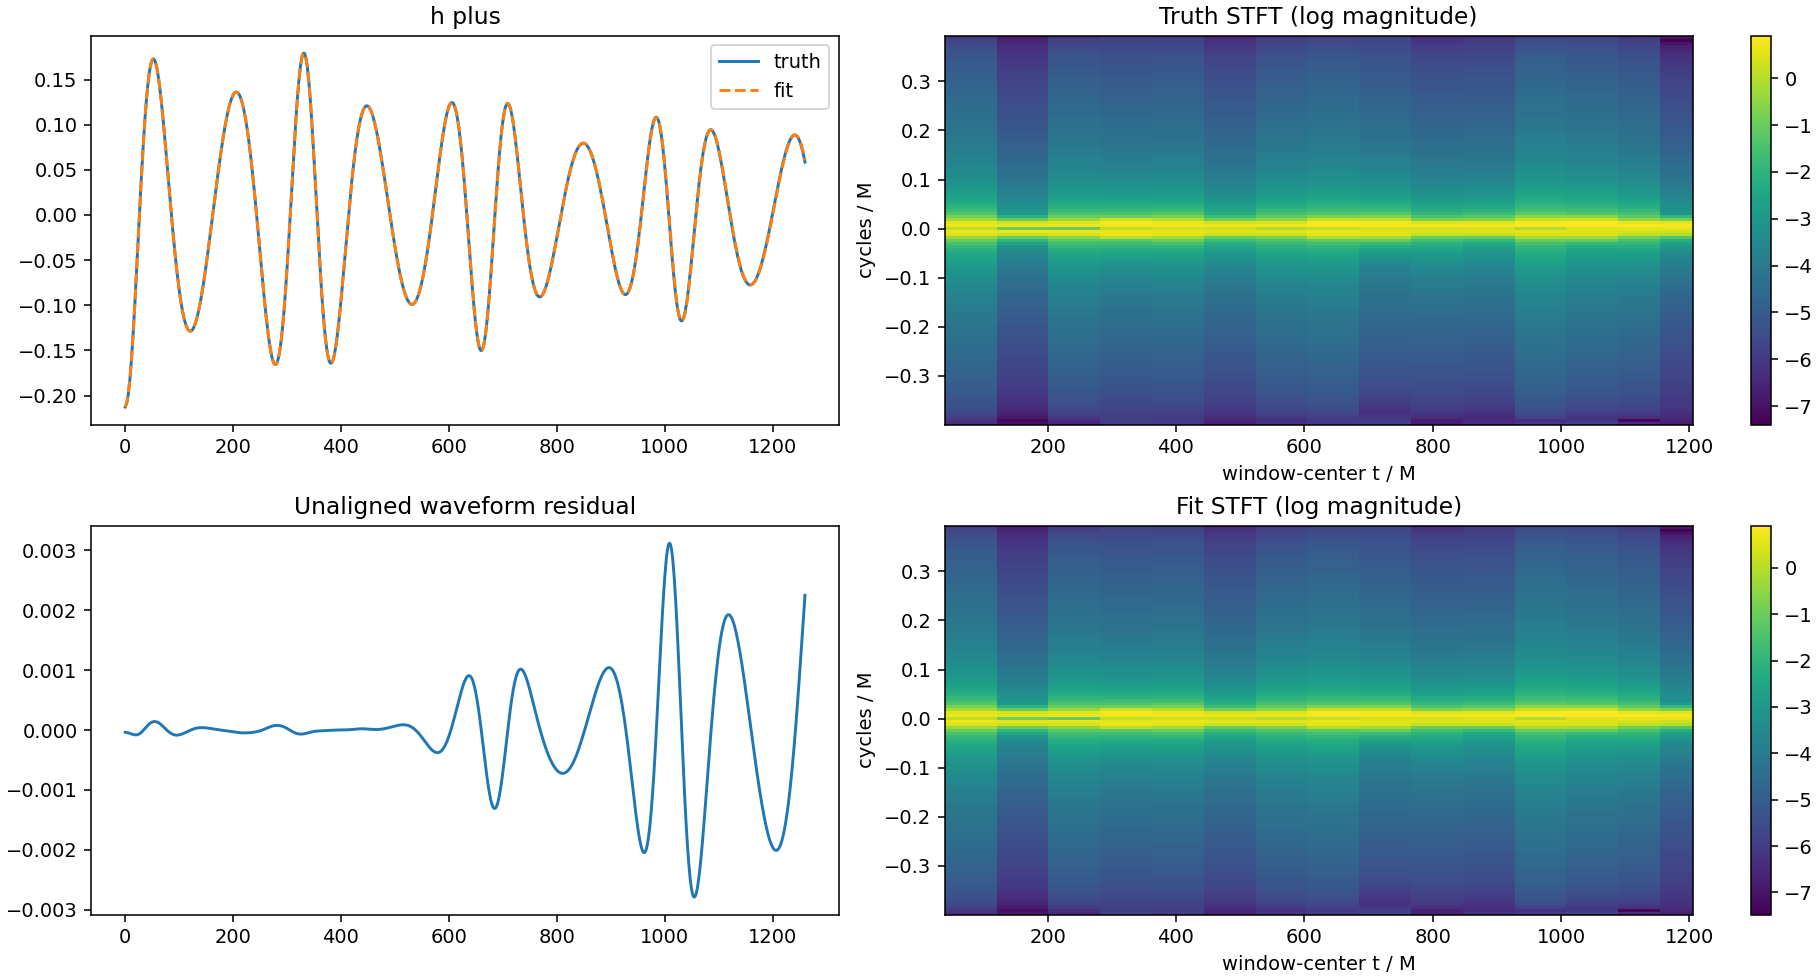

gabor : nearest coordinate-metric library entry: {'family': 'Kerr', 'spin': 0.9, 'epsilon': 0.0, 'nu': 0.0, 'distance': 0.007120921137252561, 'truth_distance': 7.171899994812611e-17}


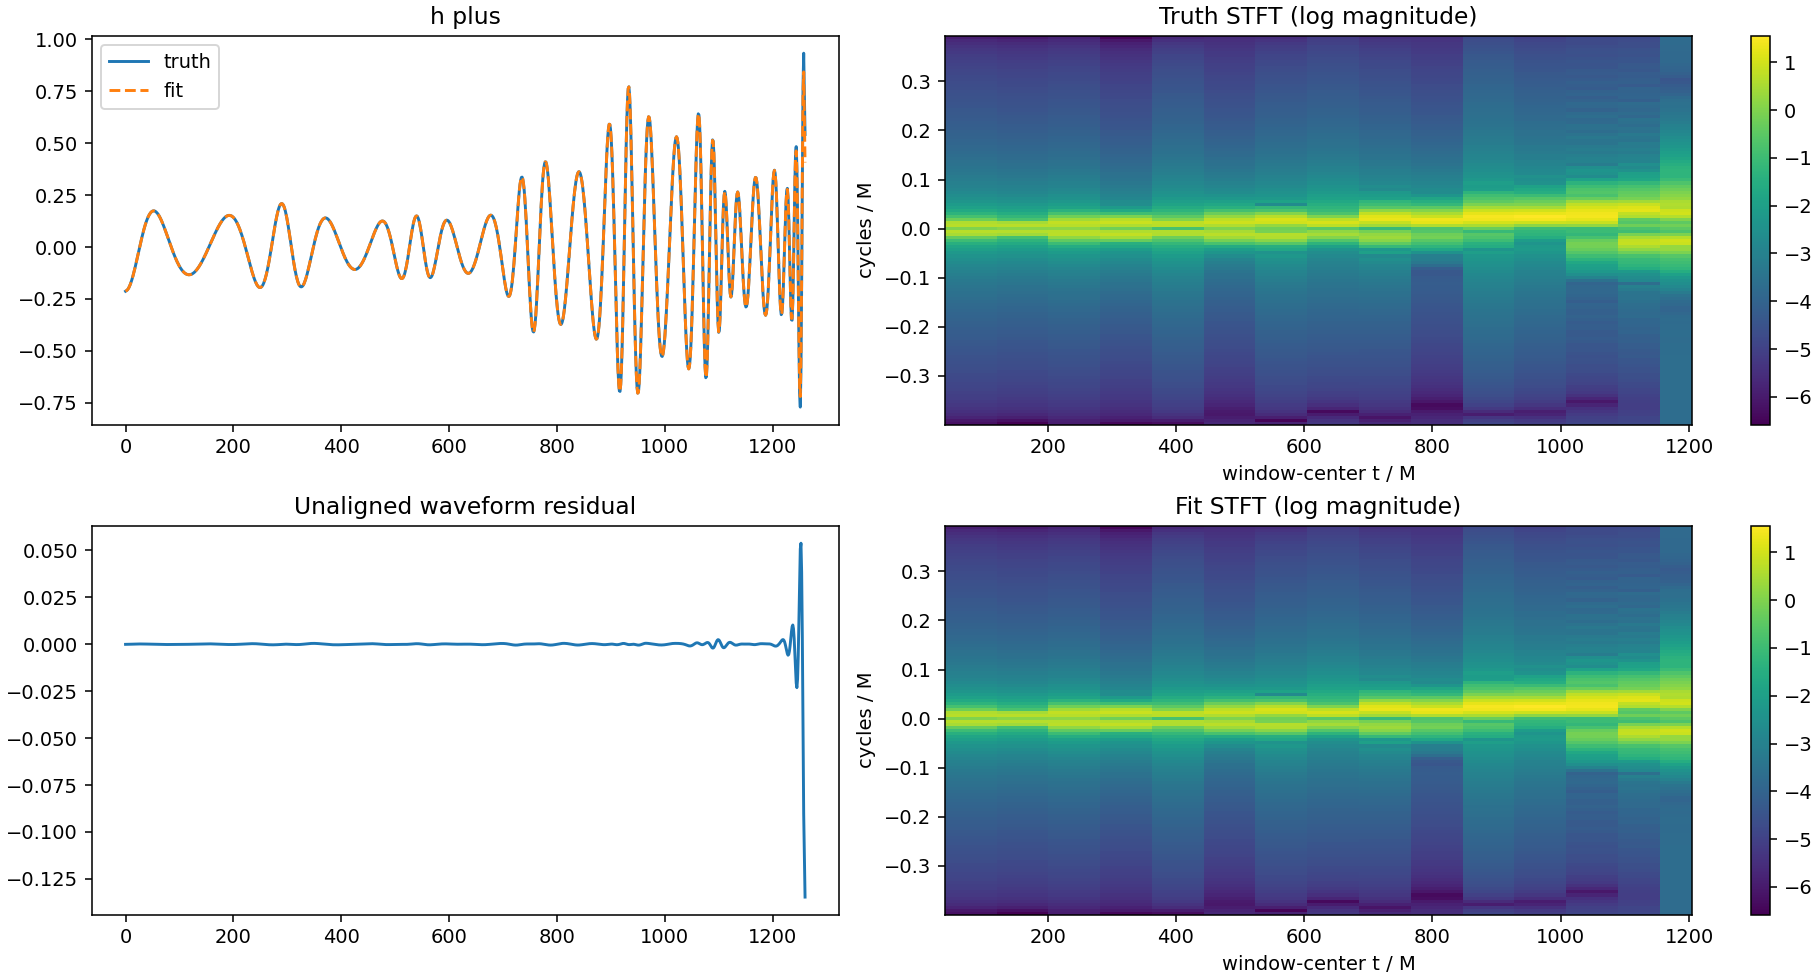

beyond_kerr : nearest coordinate-metric library entry: {'family': 'JP', 'spin': 0.9, 'epsilon': 2.0, 'nu': 0.0, 'distance': 0.009117130051096786, 'truth_distance': 6.588039089136109e-17}


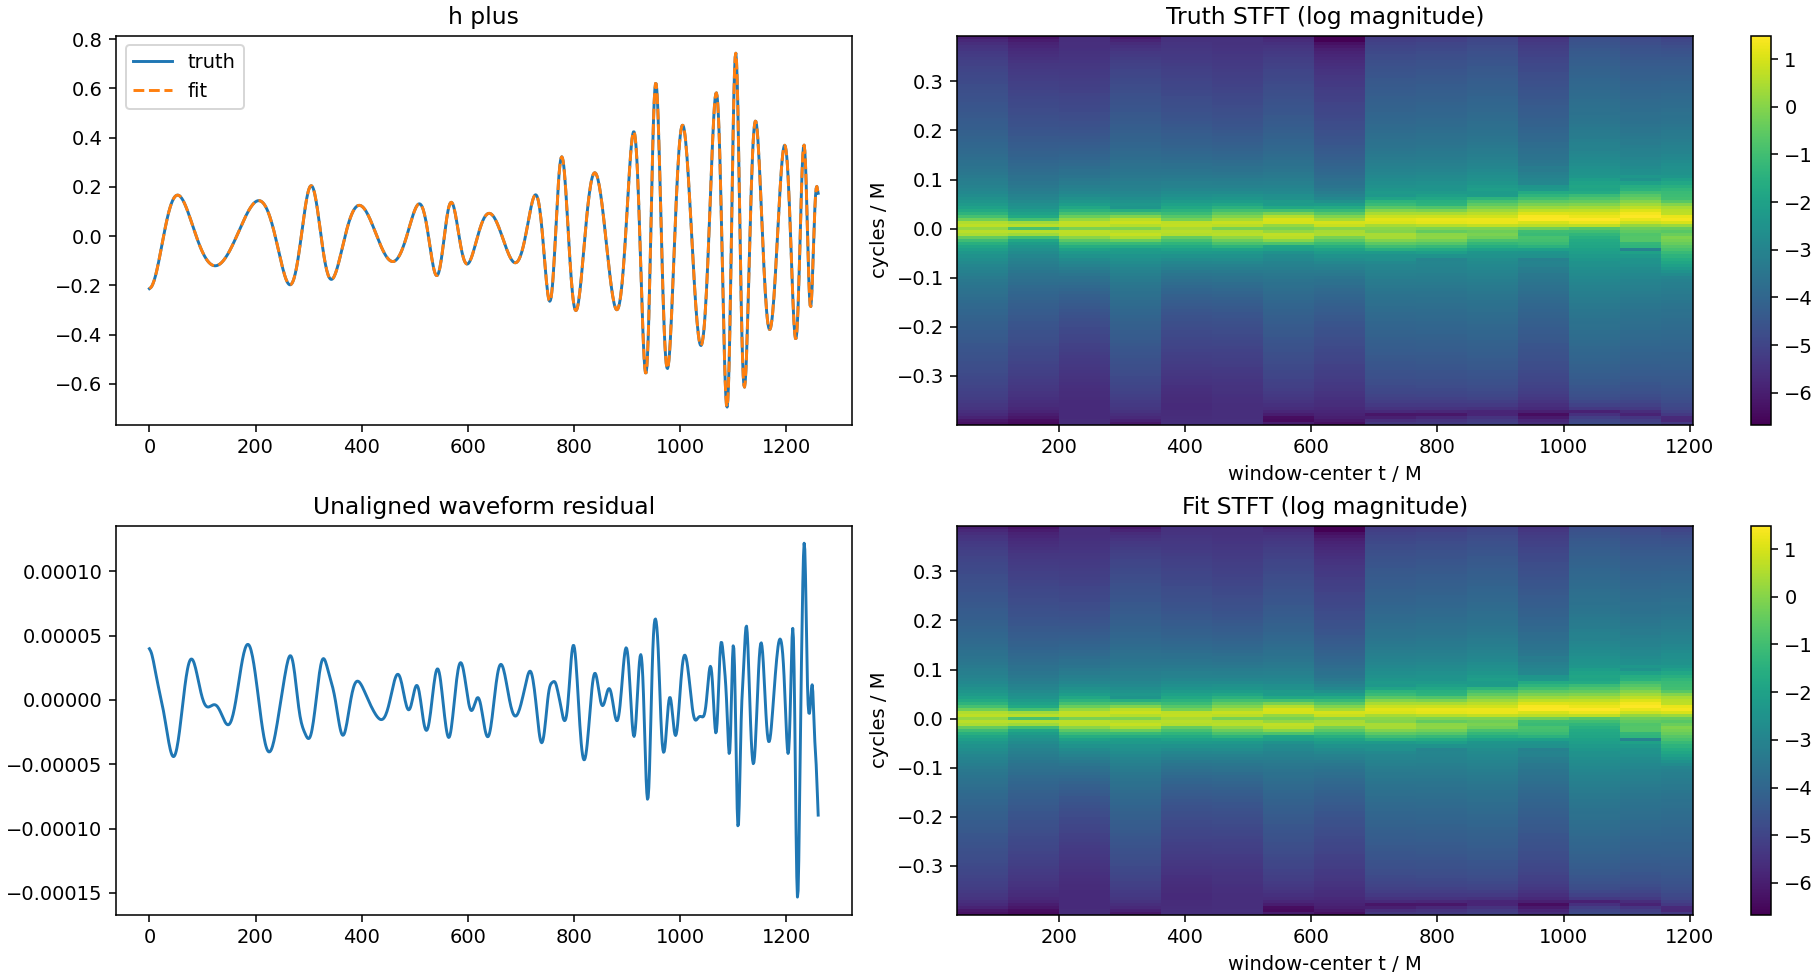

eob : nearest coordinate-metric library entry: {'family': 'EOB_toy', 'spin': 0.0, 'epsilon': 0.0, 'nu': 0.25, 'distance': 1.2080407959538266, 'truth_distance': 0.0004316876638374584}


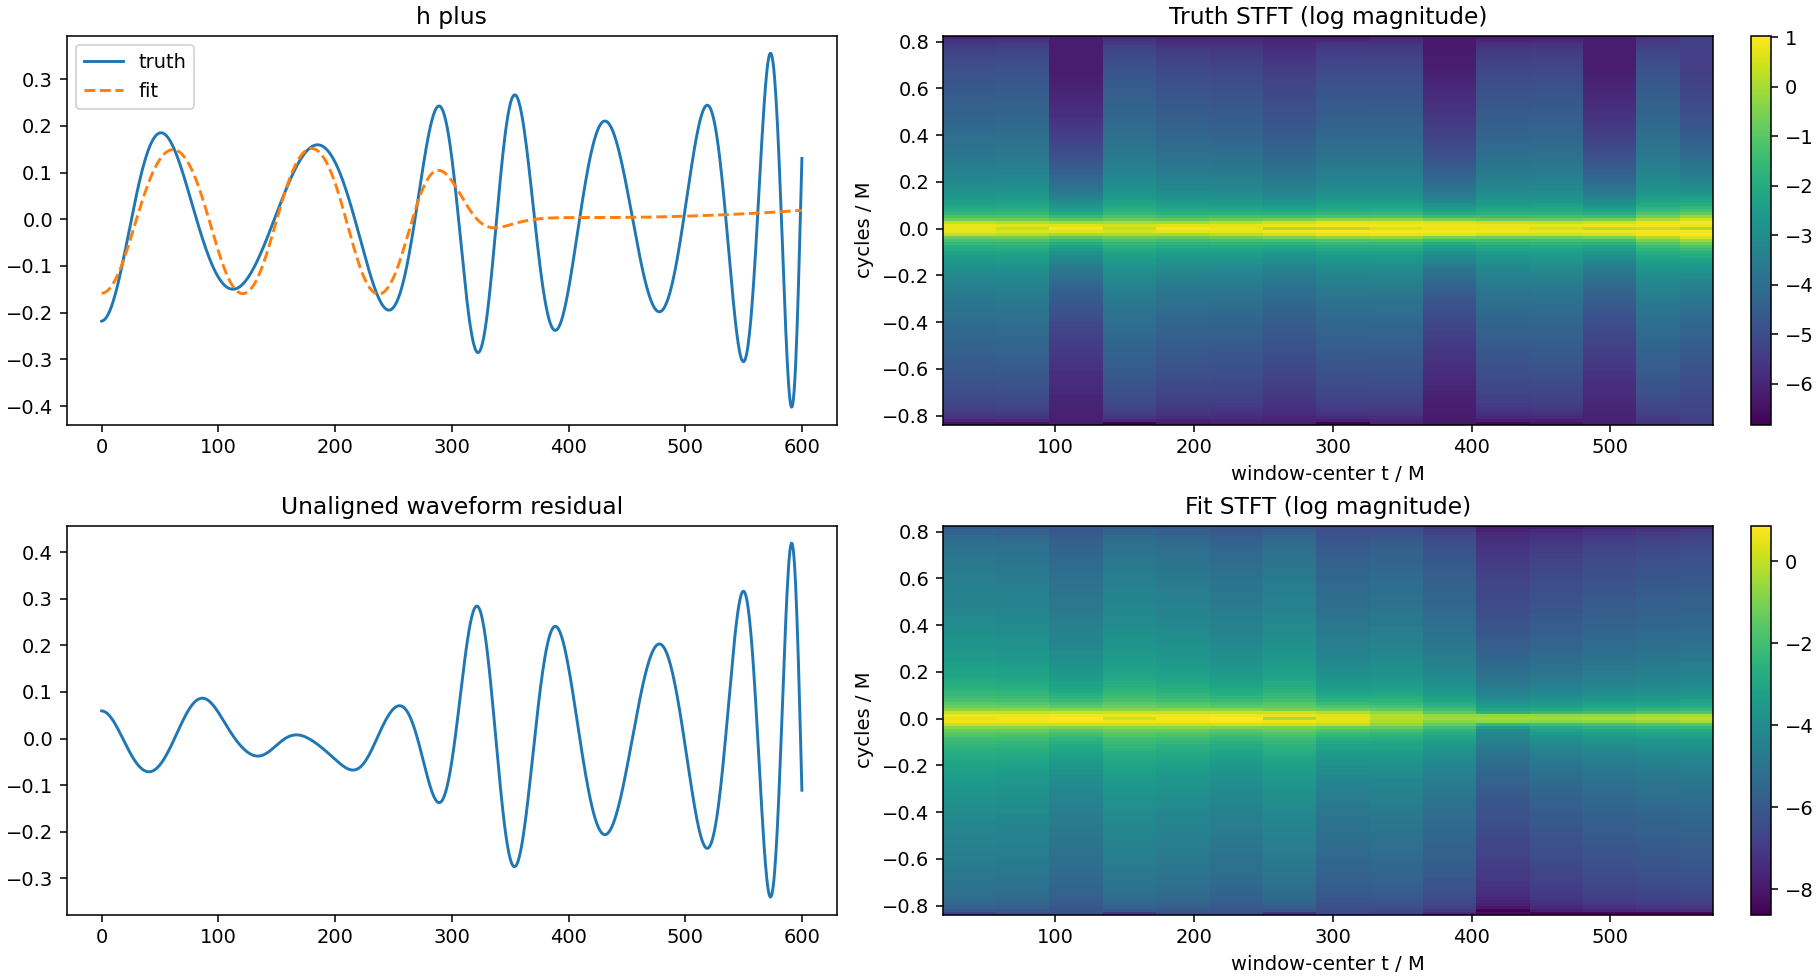

single_mode_control : 0→5M drift {'Mf': 0.06607456471614626, 'chi': 0.0014998084580843951}
overtone_injection_single_mode_fit : 0→5M drift {'Mf': 2.7944521641349596, 'chi': 0.0807797953575522}
overtone_injection_two_mode_fit : 0→5M drift {'Mf': -0.06452127685186326, 'chi': -0.0013167146693344733}


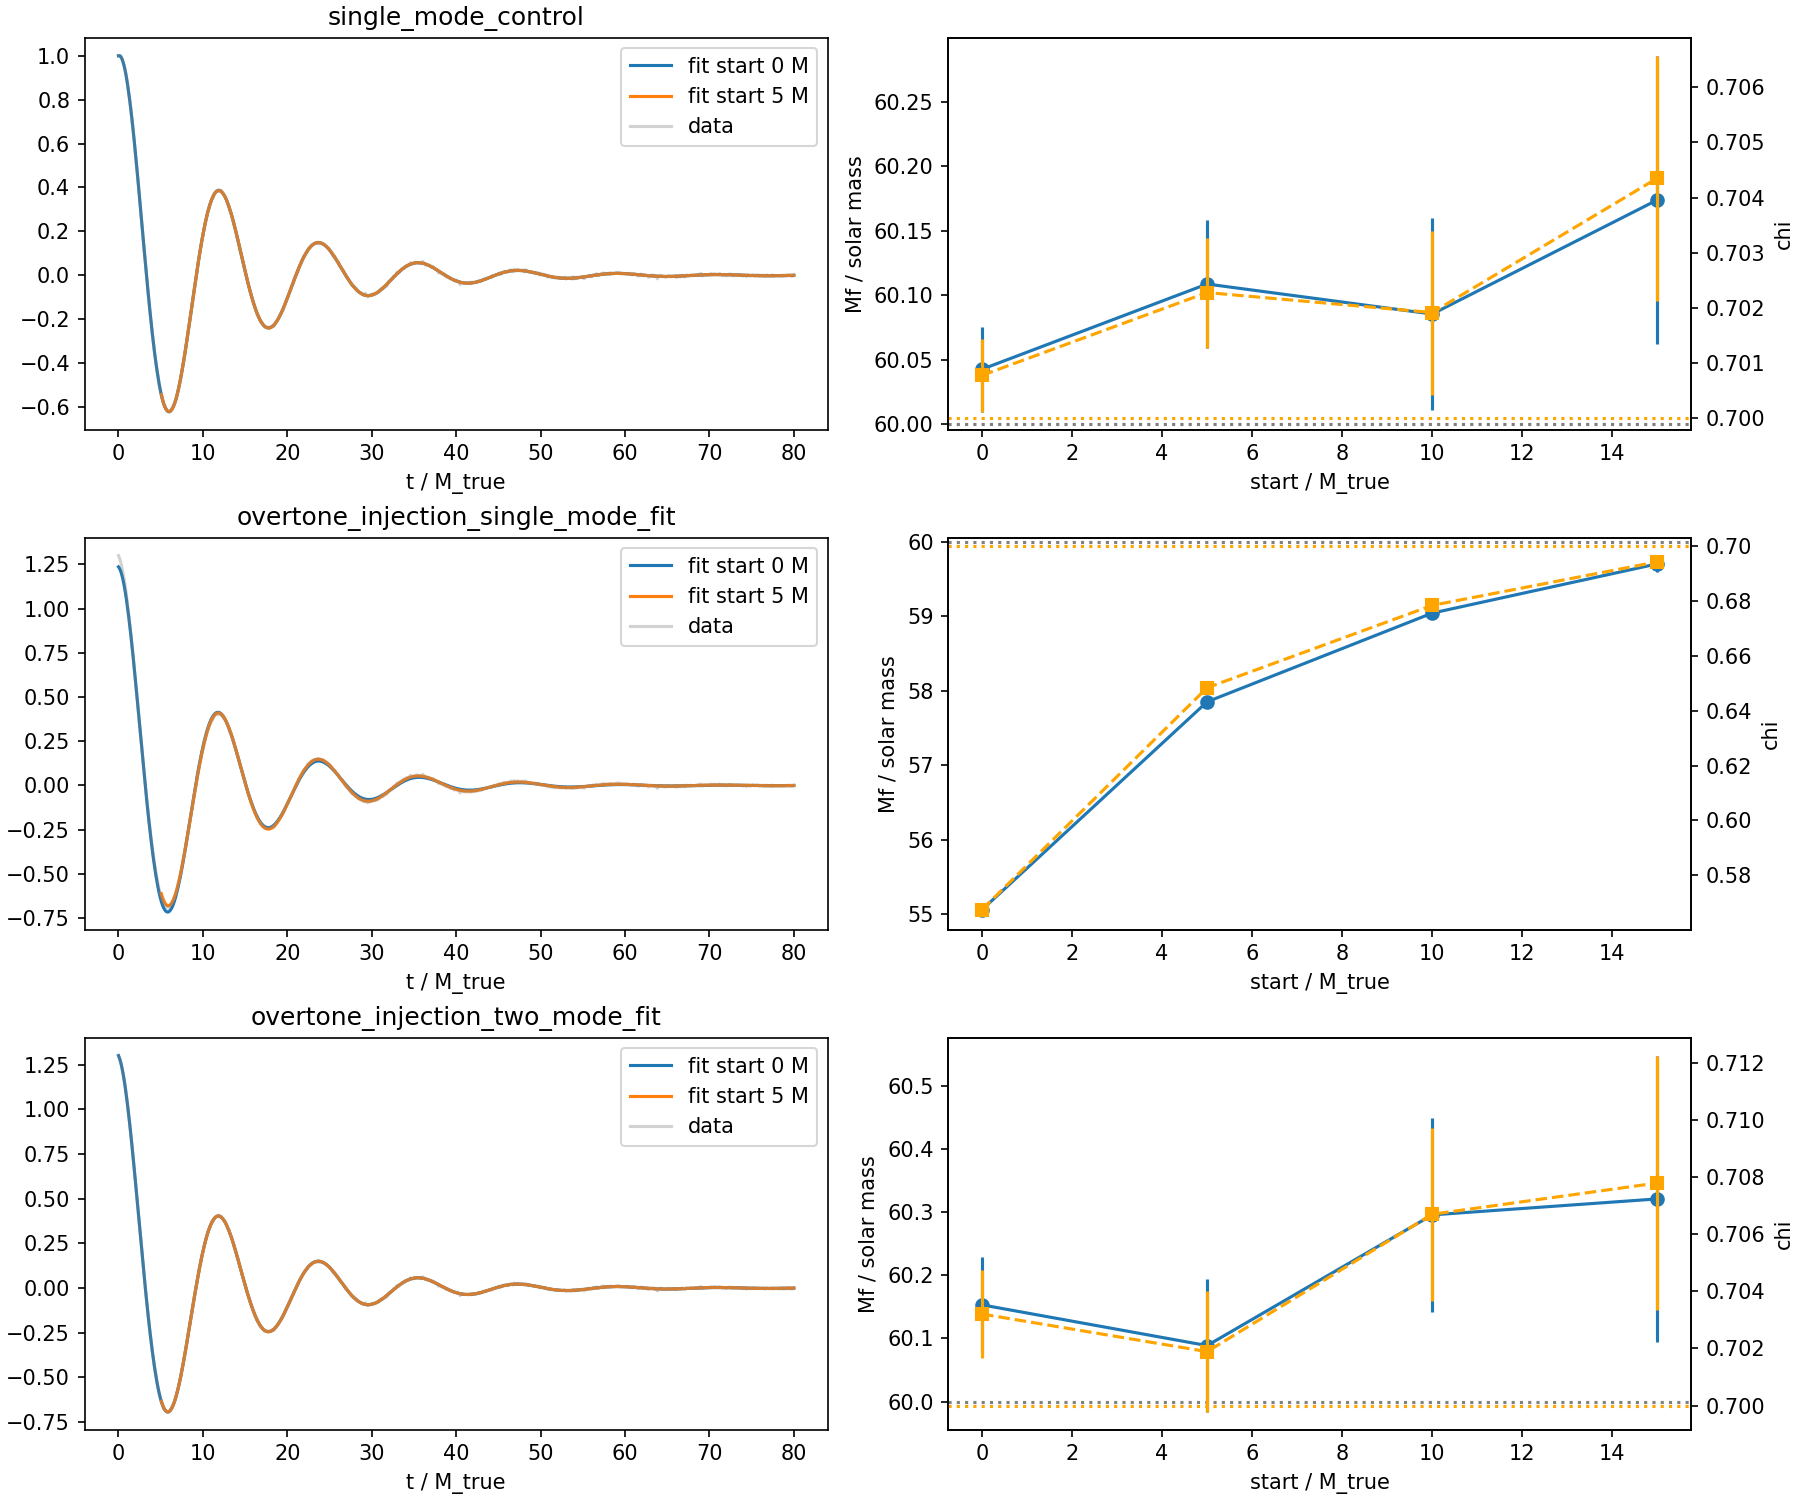

Inspect each report.json, events.jsonl, metric_errors.png, dynamics.png and jacobian.png for diagnosis.
To continue interrupted runs: keep RUN_TAG and physics settings, RESUME=True, then Run all.
dissipation additional diagnostic statuses: {'D2': 'reported', 'D5': 'reported', 'D5_amplitude_power': 'reported', 'D7': 'reported', 'D4': 'reported', 'D3': 'ok', 'D3_amplitude_power': 'ok'}
Rung D1/D3/D4: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power/dissipation/rung_diagnostics | Full-window D2–D7: /content/drive/MyDrive/Sonar_v64_runs/v64_amplitude_and_power/dissipation/extended_diagnostics
D2 totals: {'fitted': 0.00021277918271243908, 'truth_metric_truth_torque_fitted_IC': 2.743628017590126, 'truth_metric_truth_torque_truth_IC': 4.643272726682725e-09}
D7: {'shared_forward_truth_relative_L2_percent': 6.692765322815165e-12, 'dt_halving_waveform_change_percent': 0.036856015699196415, 'dissipation_imprint_percent': 2.2244343114310414, 'imprint_to_step_change': 60.35471467089541

In [14]:
# Repeatability is an optimization diagnostic, not a calibrated beyond-GR detection threshold.
import numpy as np
floor=[r for n,r in results.items() if n.startswith('floor_seed_') and 'final_components' in r]
repeatability={}
for window in sorted(set(r.get('window',0) for r in floor)):
    group=[r for r in floor if r.get('window',0)==window]
    values=[list(r.get('metric',{}).get('component_relative_L2_percent',{}).values()) for r in group]
    values=[v for v in values if len(v)==5 and all(x is not None for x in v)]
    repeatability[str(window)]={'runs':len(group),'comparable_metric_runs':len(values),
        'note':'Same last window only. Also inspect termination status, losses and budgets. Seed spread omits model bias and observational noise.'}
    if values:
        a=np.asarray(values);repeatability[str(window)].update(component_mean_percent=a.mean(axis=0).tolist(),component_std_percent=a.std(axis=0,ddof=1).tolist() if len(a)>1 else None)
(ROOT/'repeatability.json').write_text(json.dumps(repeatability,indent=2))
print('Seed repeatability by last training window:',json.dumps(repeatability,indent=2))
for name in experiments:
    r=results.get(name,{})
    if name=='ringdown':
        for case,data in r.get('cases',{}).items():print(case,': 0→5M drift',data['drift_0_to_5M'])
    else:
        nearest=r.get('metric',{}).get('nearest_library_metric')
        if nearest:print(name,': nearest coordinate-metric library entry:',nearest)
    path=ROOT/name/('ringdown.png' if name=='ringdown' else 'waveform_and_spectrogram.png')
    if path.exists():display(Image(filename=str(path),width=950))
print('Inspect each report.json, events.jsonl, metric_errors.png, dynamics.png and jacobian.png for diagnosis.')
print('To continue interrupted runs: keep RUN_TAG and physics settings, RESUME=True, then Run all.')

for name in experiments:
    if name=='ringdown':continue
    directory=ROOT/name/'extended_diagnostics'
    if (directory/'report.json').exists():
        ext=json.loads((directory/'report.json').read_text())
        print(name,'additional diagnostic statuses:',{k:v.get('status','reported') for k,v in ext.items() if isinstance(v,dict)})
        print('Rung D1/D3/D4:',ROOT/name/'rung_diagnostics','| Full-window D2–D7:',directory)
        if 'D2' in ext:
            print('D2 totals:',{k:v.get('total') for k,v in ext['D2'].items() if isinstance(v,dict)})
        if 'D7' in ext:print('D7:',ext['D7'])


## Scope and references

This notebook implements the **five mini-experiments in the latest table**. The EOB row is deliberately the proposed synthetic metric. Fitting GW190814 with a full EOB waveform model requires additional waveform, data/noise and signal-projection machinery; changing this metric alone does not implement it. `pySEOBNR` implements SEOBNRv5-family models, whereas the original GW190814 analysis used models including SEOBNRv4PHM and IMRPhenomPv3HM. No observational LIGO claim is made here.

- [GW190814 discovery and analysis](https://arxiv.org/abs/2006.12611).
- [pySEOBNR implementation and model scope](https://github.com/AEI-ACR/pyseobnr).
- [Johannsen–Psaltis parametrized metric](https://arxiv.org/abs/1105.3191); the epsilon-3 implementation here matches the attached v29 and passes its zero-deformation Kerr check.
- [qnm documentation and conventions](https://qnm.readthedocs.io/en/latest/README.html).
- [Isi and Farr: Analyzing black-hole ringdowns](https://arxiv.org/abs/2107.05609).

JP injections here use the same kinematic quadrupole map as the learner, not a gravitational-perturbation calculation for a specified modified theory. Turning off Ricci removes a restrictive prior; it does not supply modified field equations or guarantee identifiability. Coordinate-component errors and library distances are meaningful only in the fixed ansatz/chart used here.


## Validation performed before delivery

All five branches completed shortened CPU runs (one Adam epoch and two LM evaluations for each orbit branch), with all notebook code cells executed in order under IPython. The Gabor smoke run used multiple windows. These checks validate execution, not metric recovery or convergence. Ringdown controls, full-length target gates, finite checkpoint handling, and the plotting writer were also exercised.

The preserved global-FFT objective and residual matched v23 numerically at a test point; the full-window STFT special case matched the FFT residual. Zero-deformation JP and zero-nu EOB recovered Kerr and Schwarzschild respectively. Full overnight optimization and the ten-seed ensemble have **not** been run here.

Validation environment: Python 3.12, JAX 0.11.1 (CPU), NumPy 2.3.5, SciPy 1.17.0, qnm 0.4.4. Your runtime versions/devices are recorded in each orbit run's preflight report. The notebook retains your existing JAX installation to avoid replacing Colab's GPU build.


D0–D7 were subsequently integrated from `Pasted text(1).txt`. At the tested point, both the residual vector and its Jacobian matched the preceding v64 exactly (maximum absolute differences: 0). Short Gabor and JP runs exercised the added diagnostics, and the updated notebook cells were executed in order for a short balanced-dissipation run. The latter checked direct energy balance and shared truth-forward agreement. Flat/zero and nonfinite amplitude-profile cases were also checked. These tests establish execution and consistency, not scientific convergence.


The amplitude/exponent revision passed: preservation of the previous injected force at n=3.5; analytic torque derivatives and mass-shell orthogonality at several exponents; finite-difference checks of both amplitude and exponent residual-Jacobian columns; a 75-parameter training/diagnostics run; a notebook-level short run; and restoration of a 75-parameter checkpoint including the fitted exponent. Both amplitude and exponent changed during the short optimization. These smoke runs do not establish recovery of the injected exponent or full convergence.
